# Bridge_final-3 Follow-up Experiments

이 노트북은 `Bridge_final-3.ipynb`를 기준으로 만든 **분석 전용 파이프라인**입니다.

목표는 Bridge를 다시 학습하는 것이 아니라, `Bridge_final-3`에서 저장한 latent/checkpoint를 불러와 다음을 확인하는 것입니다.

- Latent collapse 진단
- Retrieval + baseline + condition ablation
- Per-drug / group-level retrieval
- Direction asymmetry
- SMILES decoder 기반 Tanimoto gap
- Modification residual analysis
- M2S sequence decode sanity check
- PCA alignment visualization
- Full cycle round-trip
- Cross-modal disagreement interpolation

> 전제: `Bridge_final-3.ipynb`를 한 번 실행해 `bridge_latents.csv`, `bridge_s2m.pt`, `bridge_m2s.pt`, `bridge_scalers.pkl`, `bridge_config.json`이 생성되어 있어야 합니다.


## 0. Setup


In [1]:
# 필요시 주석 해제
!pip install -q rdkit selfies scikit-learn matplotlib joblib

import os, json, pickle, random, warnings, math
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.cross_decomposition import CCA
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity

import matplotlib.pyplot as plt

from IPython.display import display

warnings.filterwarnings('ignore')

try:
    from rdkit import Chem, RDLogger
    from rdkit.Chem import AllChem, DataStructs, Descriptors, rdMolDescriptors
    RDLogger.DisableLog('rdApp.*')
except Exception as e:
    raise ImportError('RDKit이 필요합니다. 설치 후 다시 실행하세요.') from e

try:
    import selfies as sf
except Exception as e:
    raise ImportError('selfies 패키지가 필요합니다. 설치 후 다시 실행하세요.') from e

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('DEVICE:', DEVICE)


DEVICE: cuda


## 1. Paths and prerequisites

기본 경로는 `Bridge_final-3.ipynb`와 동일하게 `./MLProject`입니다. 필요하면 아래 경로만 수정하세요.


In [ ]:
from pathlib import Path
import os

# ===== Colab 환경 자동 설정 =====
# Colab이면 Google Drive를 마운트하고, 아니면 로컬 경로를 사용합니다.
try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB and not os.path.ismount('/content/drive'):
    from google.colab import drive
    drive.mount('/content/drive')

# === BASE_DIR: dataset/ 와 bridge/ 가 들어있는 MLProject 폴더 위치 ===
# 본인 Drive 구조에 맞게 아래 후보 경로만 수정하면 됩니다.
# 가장 먼저 존재하는 경로가 자동 선택됩니다.
_BASE_CANDIDATES = [
    Path('/content/drive/MyDrive/MLProject'),  # Drive 루트에 MLProject가 있는 경우
    Path('/content/MLProject'),                # Colab 세션에 직접 업로드한 경우
    Path('./MLProject'),                       # 로컬 실행
]
BASE_DIR = next((p for p in _BASE_CANDIDATES if p.exists()), _BASE_CANDIDATES[0])
print('BASE_DIR =>', BASE_DIR, '| exists:', BASE_DIR.exists())

DATA_DIR = BASE_DIR / 'dataset'
OUT_DIR = BASE_DIR / 'bridge'
EXP_DIR = OUT_DIR / 'bridge_final3_followup_experiments'
FIG_DIR = EXP_DIR / 'figures'
TAB_DIR = EXP_DIR / 'tables'
CACHE_DIR = EXP_DIR / 'cache'

for d in [EXP_DIR, FIG_DIR, TAB_DIR, CACHE_DIR]:
    d.mkdir(parents=True, exist_ok=True)

LATENT_PATH = OUT_DIR / 'bridge_latents.csv'
BRIDGE_S2M_PATH = OUT_DIR / 'bridge_s2m.pt'
BRIDGE_M2S_PATH = OUT_DIR / 'bridge_m2s.pt'
SCALER_PATH = OUT_DIR / 'bridge_scalers.pkl'
CONFIG_PATH = OUT_DIR / 'bridge_config.json'

# Sequence Model
SEQ_CKPT_PATH = f"{BASE_DIR}/sequence/sequence_cvae_checkpoint.pt"
# SMILES Model
SMILES_META_PATH = f"{BASE_DIR}/smiles/metadata.json"
SMILES_CKPT_PATH = f"{BASE_DIR}/smiles/cvae_gru_ep0500.pt"

required = [LATENT_PATH, BRIDGE_S2M_PATH, BRIDGE_M2S_PATH, CONFIG_PATH, SEQ_CKPT_PATH, SMILES_CKPT_PATH]
for p in required + [SCALER_PATH, SMILES_META_PATH]:
    print(str(p), '=>', p.exists())

missing = [str(p) for p in required if not p.exists()]
if missing:
    raise FileNotFoundError('필수 파일이 없습니다. Bridge.ipynb를 먼저 실행하세요:\n' + '\n'.join(missing))


## 2. Load latent table and reproduce split

`Bridge_final-3`와 같은 방식으로 train/val/test split을 재현합니다.

- train/val: weak_generated pair
- test: real_milestone pair


In [3]:
latent_df = pd.read_csv(LATENT_PATH)
print('latent_df:', latent_df.shape)
print(latent_df['pair_type'].value_counts())

def normalize_condition_string(s):
    if pd.isna(s):
        return '000'
    s = str(s).strip()
    if s.endswith('.0'):
        s = s[:-2]
    return s.zfill(3)

latent_df['condition'] = latent_df['condition'].apply(normalize_condition_string)
latent_df['name'] = latent_df['name'].astype(str)

import re
z_seq_cols = [c for c in latent_df.columns if re.fullmatch(r'z_seq_\d+', c)]
z_smi_cols = [c for c in latent_df.columns if re.fullmatch(r'z_smi_\d+', c)]
z_seq_cols = sorted(z_seq_cols, key=lambda x: int(x.split('_')[-1]))
z_smi_cols = sorted(z_smi_cols, key=lambda x: int(x.split('_')[-1]))

Z_seq_raw = latent_df[z_seq_cols].values.astype('float32')
Z_smi_raw = latent_df[z_smi_cols].values.astype('float32')
C_raw = latent_df[['GLP1R', 'GIPR', 'GCGR']].values.astype('float32')
names_all = latent_df['name'].astype(str).values
cond_all = latent_df['condition'].astype(str).values

SEQ_LATENT_DIM = Z_seq_raw.shape[1]
SMI_LATENT_DIM = Z_smi_raw.shape[1]
print('Z_seq_raw:', Z_seq_raw.shape, 'Z_smi_raw:', Z_smi_raw.shape)

is_weak = latent_df['pair_type'].eq('weak_generated').values
is_real = latent_df['pair_type'].eq('real_milestone').values
weak_idx = np.where(is_weak)[0]
te_idx = np.where(is_real)[0]

strat = latent_df.iloc[weak_idx]['condition'].astype(str).values
try:
    tr_idx, va_idx = train_test_split(weak_idx, test_size=0.15, random_state=SEED, stratify=strat)
except ValueError:
    tr_idx, va_idx = train_test_split(weak_idx, test_size=0.15, random_state=SEED)

print(f'train weak={len(tr_idx)} | val weak={len(va_idx)} | test real={len(te_idx)}')
display(latent_df.iloc[te_idx][['name','condition','pair_type']].reset_index(drop=True))


latent_df: (457, 170)
pair_type
weak_generated    445
real_milestone     12
Name: count, dtype: int64
Z_seq_raw: (457, 32) Z_smi_raw: (457, 128)
train weak=378 | val weak=67 | test real=12


,name,condition,pair_type
0,GLP-1(7-36),100,real_milestone
1,GIP(1-42),010,real_milestone
2,Glucagon(1-29),001,real_milestone
3,Exenatide,100,real_milestone
4,Lixisenatide,100,real_milestone
5,Liraglutide,100,real_milestone
6,Albiglutide,100,real_milestone
7,Taspoglutide,100,real_milestone
8,Dulaglutide,100,real_milestone
9,Semaglutide,100,real_milestone


## 3. Load scalers and trained Bridge checkpoint

Bridge는 scaled latent space에서 학습되었으므로, 저장된 scaler를 우선 사용합니다.


In [4]:
if SCALER_PATH.exists():
    with open(SCALER_PATH, 'rb') as f:
        sc_obj = pickle.load(f)
    seq_scaler = sc_obj['seq_scaler']
    smi_scaler = sc_obj['smi_scaler']
    print('Loaded scalers from:', SCALER_PATH)
else:
    print('[WARN] bridge_scalers.pkl 없음: train split으로 scaler를 재생성합니다.')
    seq_scaler = StandardScaler().fit(Z_seq_raw[tr_idx])
    smi_scaler = StandardScaler().fit(Z_smi_raw[tr_idx])

Z_seq = seq_scaler.transform(Z_seq_raw).astype('float32')
Z_smi = smi_scaler.transform(Z_smi_raw).astype('float32')

with open(CONFIG_PATH, 'r') as f:
    bridge_config = json.load(f)
print(json.dumps(bridge_config, indent=2))

USE_COND_INPUT = bool(bridge_config.get('use_cond_input', True))
BRIDGE_HIDDEN = int(bridge_config.get('hidden', 96))
BRIDGE_DROPOUT = float(bridge_config.get('dropout', 0.15))

class Bridge(nn.Module):
    def __init__(self, in_dim, out_dim, cond_dim=3, hidden_dim=96, dropout=0.15, use_cond=True):
        super().__init__()
        self.use_cond = use_cond
        d_in = in_dim + (cond_dim if use_cond else 0)
        self.net = nn.Sequential(
            nn.Linear(d_in, hidden_dim), nn.LayerNorm(hidden_dim), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim), nn.LayerNorm(hidden_dim), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(hidden_dim, out_dim),
        )
    def forward(self, z, cond=None):
        if self.use_cond and cond is not None:
            z = torch.cat([z, cond], dim=1)
        return self.net(z)

bridge_s2m = Bridge(SEQ_LATENT_DIM, SMI_LATENT_DIM, hidden_dim=BRIDGE_HIDDEN, dropout=BRIDGE_DROPOUT, use_cond=USE_COND_INPUT).to(DEVICE)
bridge_m2s = Bridge(SMI_LATENT_DIM, SEQ_LATENT_DIM, hidden_dim=BRIDGE_HIDDEN, dropout=BRIDGE_DROPOUT, use_cond=USE_COND_INPUT).to(DEVICE)

bridge_s2m.load_state_dict(torch.load(BRIDGE_S2M_PATH, map_location=DEVICE))
bridge_m2s.load_state_dict(torch.load(BRIDGE_M2S_PATH, map_location=DEVICE))
bridge_s2m.eval(); bridge_m2s.eval()
print('Loaded trained Bridge checkpoints.')

@torch.no_grad()
def predict_s2m(idx):
    z = torch.tensor(Z_seq[idx], dtype=torch.float32, device=DEVICE)
    c = torch.tensor(C_raw[idx], dtype=torch.float32, device=DEVICE)
    return bridge_s2m(z, c).cpu().numpy()

@torch.no_grad()
def predict_m2s(idx):
    z = torch.tensor(Z_smi[idx], dtype=torch.float32, device=DEVICE)
    c = torch.tensor(C_raw[idx], dtype=torch.float32, device=DEVICE)
    return bridge_m2s(z, c).cpu().numpy()

s2m_pred_val = predict_s2m(va_idx)
m2s_pred_val = predict_m2s(va_idx)
s2m_pred_te = predict_s2m(te_idx)
m2s_pred_te = predict_m2s(te_idx)
print('Predictions ready.')


Loaded scalers from: MLProject/bridge/bridge_scalers.pkl
{
  "seq_latent_dim": 32,
  "smi_latent_dim": 128,
  "use_cond_input": true,
  "hidden": 96,
  "dropout": 0.15,
  "loss_kw": {
    "w_nce": 1.0,
    "w_mse": 0.2,
    "w_cycle": 0.1,
    "temp": 0.1
  },
  "split": {
    "train": 378,
    "val": 67,
    "test": 12
  }
}
Loaded trained Bridge checkpoints.
Predictions ready.


# Tier 1 — Core Bridge diagnostics


## 4. Latent collapse diagnosis

Bridge 성능을 해석하기 전에, upstream latent space가 실제로 몇 차원 정도 살아있는지 확인합니다.


,space,n,dim,effective_dim,active_dim_var_gt_1e-3,mean_abs_offdiag_corr,condition_var_explained,min_var,max_var
0,z_seq_raw,457,32,2.198844,32,0.489595,0.645653,0.108462,3.865159
1,z_smi_raw,457,128,2.046952,128,0.538268,0.322255,0.002137,0.064328
2,z_seq_scaled,457,32,2.973562,32,0.489595,0.577087,0.968005,1.031704
3,z_smi_scaled,457,128,2.710124,128,0.538268,0.300305,1.004990,1.156678


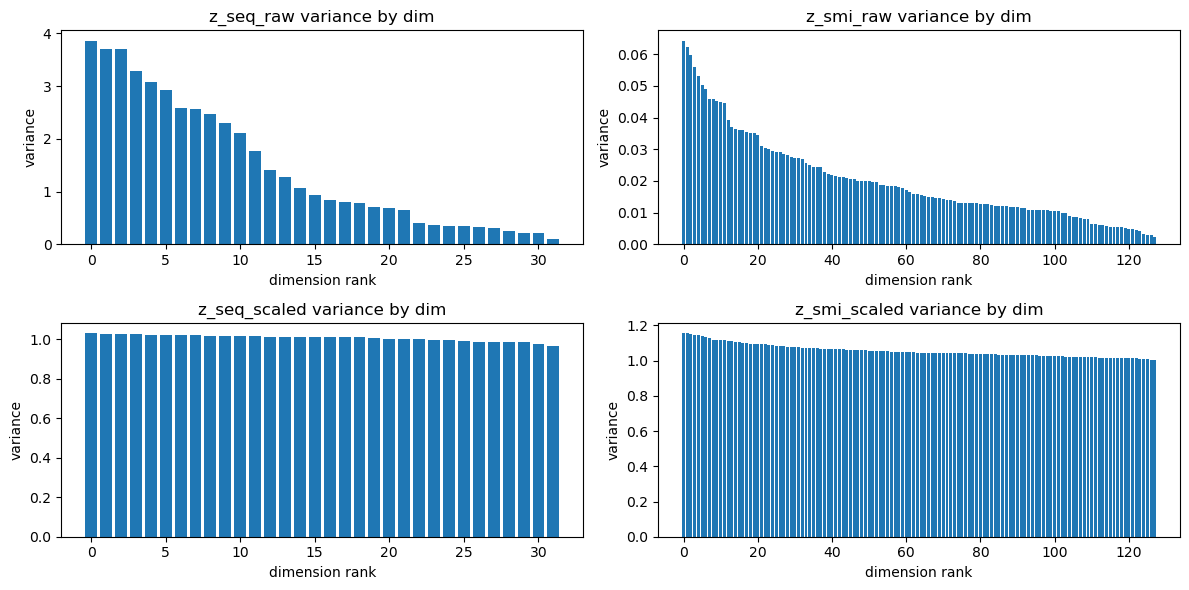

In [5]:
def effective_dim(Z):
    Zc = Z - Z.mean(axis=0, keepdims=True)
    cov = np.cov(Zc, rowvar=False)
    ev = np.linalg.eigvalsh(cov)
    ev = ev[ev > 1e-12]
    return float((ev.sum() ** 2) / (np.square(ev).sum() + 1e-12)) if len(ev) else 0.0

def active_dim(Z, thresh=1e-3):
    return int((Z.var(axis=0) > thresh).sum())

def offdiag_corr(Z):
    C = np.corrcoef(Z.T)
    mask = ~np.eye(C.shape[0], dtype=bool)
    return float(np.nanmean(np.abs(C[mask])))

def cond_var_explained(Z, cond_str):
    Zc = Z - Z.mean(axis=0, keepdims=True)
    total = np.square(Zc).sum() + 1e-12
    resid = 0.0
    for c in np.unique(cond_str):
        m = cond_str == c
        resid += np.square(Zc[m] - Zc[m].mean(axis=0, keepdims=True)).sum()
    return float(1 - resid / total)

def diag_row(name, Z):
    return {
        'space': name,
        'n': Z.shape[0],
        'dim': Z.shape[1],
        'effective_dim': effective_dim(Z),
        'active_dim_var_gt_1e-3': active_dim(Z, 1e-3),
        'mean_abs_offdiag_corr': offdiag_corr(Z),
        'condition_var_explained': cond_var_explained(Z, cond_all),
        'min_var': float(Z.var(axis=0).min()),
        'max_var': float(Z.var(axis=0).max()),
    }

latent_diag = pd.DataFrame([
    diag_row('z_seq_raw', Z_seq_raw),
    diag_row('z_smi_raw', Z_smi_raw),
    diag_row('z_seq_scaled', Z_seq),
    diag_row('z_smi_scaled', Z_smi),
])
latent_diag.to_csv(TAB_DIR / 'latent_collapse_diagnostics.csv', index=False)
display(latent_diag)

fig, axes = plt.subplots(2, 2, figsize=(12, 6))
for ax, (title, Z) in zip(axes.ravel(), [('z_seq_raw', Z_seq_raw), ('z_smi_raw', Z_smi_raw), ('z_seq_scaled', Z_seq), ('z_smi_scaled', Z_smi)]):
    v = np.sort(Z.var(axis=0))[::-1]
    ax.bar(np.arange(len(v)), v)
    ax.set_title(f'{title} variance by dim')
    ax.set_xlabel('dimension rank')
    ax.set_ylabel('variance')
plt.tight_layout()
plt.savefig(FIG_DIR / 'latent_variance_sorted.png', dpi=200, bbox_inches='tight')
plt.show()


## 5. Retrieval utilities


In [6]:
def l2_normalize(X):
    return X / (np.linalg.norm(X, axis=1, keepdims=True) + 1e-12)

def cosine_rows(a, b):
    return np.sum(l2_normalize(a) * l2_normalize(b), axis=1)

def retrieval_orders(pred, bank):
    sims = cosine_similarity(pred, bank)
    order = np.argsort(-sims, axis=1)
    return sims, order

def retrieval_metrics(pred, bank, q_names, bank_names, ks=(1, 3, 5)):
    sims, order = retrieval_orders(pred, bank)
    rows = []
    ranks = []
    for i, q in enumerate(q_names):
        ranked_names = [bank_names[j] for j in order[i]]
        try:
            rank = ranked_names.index(q) + 1
        except ValueError:
            rank = np.inf
        ranks.append(rank)
    out = {}
    for k in ks:
        kk = min(k, bank.shape[0])
        out[f'top{k}'] = float(np.mean([r <= kk for r in ranks]))
    out['MRR'] = float(np.mean([0 if not np.isfinite(r) else 1.0 / r for r in ranks]))
    out['mean_rank'] = float(np.mean([r if np.isfinite(r) else bank.shape[0] + 1 for r in ranks]))
    return out

def random_expected(n_bank, ks=(1,3,5)):
    out = {f'top{k}': min(k, n_bank) / max(1, n_bank) for k in ks}
    # expected MRR for a uniform random rank among 1..N
    out['MRR'] = float(np.mean([1.0 / r for r in range(1, max(1, n_bank) + 1)]))
    out['mean_rank'] = (n_bank + 1) / 2
    return out

def nearest_table(pred, bank, q_names, bank_names, q_cond=None, bank_cond=None, topk=5):
    sims, order = retrieval_orders(pred, bank)
    rows = []
    for i, q in enumerate(q_names):
        ranked_idx = order[i, :min(topk, bank.shape[0])]
        ranked_names = [bank_names[j] for j in ranked_idx]
        ranked_sims = [float(sims[i, j]) for j in ranked_idx]
        full_names = [bank_names[j] for j in order[i]]
        rank = full_names.index(q) + 1 if q in full_names else None
        row = {
            'query': q,
            'true_condition': q_cond[i] if q_cond is not None else None,
            'top1': ranked_names[0],
            'top1_condition': bank_cond[ranked_idx[0]] if bank_cond is not None else None,
            'top1_correct': ranked_names[0] == q,
            'self_rank': rank,
            'top_names': ranked_names,
            'top_sims': [round(x, 3) for x in ranked_sims],
        }
        rows.append(row)
    return pd.DataFrame(rows)


## 6. Retrieval with baselines and condition ablation

여기서는 MLP Bridge뿐 아니라 다음 baseline을 비교합니다.

- Random expected
- Ridge z-only: `z_seq → z_smi`, `z_smi → z_seq`
- Ridge z+condition
- Condition-only Ridge: `condition → z`
- Condition-centroid: 같은 condition을 가진 train target의 평균 latent

핵심 질문은 **Bridge가 sequence latent 정보를 쓰는지, 아니면 condition label만으로 대부분 설명되는지**입니다.


In [7]:
def fit_ridge_and_predict(X_train, Y_train, X_eval, alpha=1.0):
    model = Ridge(alpha=alpha).fit(X_train, Y_train)
    return model.predict(X_eval), model

def cond_centroid_predict(C_train, Y_train, C_eval):
    # condition tuple별 target centroid. unseen condition은 global mean 사용.
    keys = [tuple(map(int, c)) for c in C_train]
    centroids = {}
    for k in sorted(set(keys)):
        m = np.array([kk == k for kk in keys])
        centroids[k] = Y_train[m].mean(axis=0)
    global_mean = Y_train.mean(axis=0)
    preds = []
    for c in C_eval:
        k = tuple(map(int, c))
        preds.append(centroids.get(k, global_mean))
    return np.vstack(preds).astype('float32')

# Baseline predictions
X_seq_cond_tr = np.hstack([Z_seq[tr_idx], C_raw[tr_idx]])
X_smi_cond_tr = np.hstack([Z_smi[tr_idx], C_raw[tr_idx]])
X_seq_cond_val = np.hstack([Z_seq[va_idx], C_raw[va_idx]])
X_smi_cond_val = np.hstack([Z_smi[va_idx], C_raw[va_idx]])
X_seq_cond_te = np.hstack([Z_seq[te_idx], C_raw[te_idx]])
X_smi_cond_te = np.hstack([Z_smi[te_idx], C_raw[te_idx]])

baseline_preds = {}
# val
baseline_preds[('val','MLP_S2M')] = s2m_pred_val
baseline_preds[('val','MLP_M2S')] = m2s_pred_val
baseline_preds[('val','Ridge_zonly_S2M')] = fit_ridge_and_predict(Z_seq[tr_idx], Z_smi[tr_idx], Z_seq[va_idx])[0]
baseline_preds[('val','Ridge_zonly_M2S')] = fit_ridge_and_predict(Z_smi[tr_idx], Z_seq[tr_idx], Z_smi[va_idx])[0]
baseline_preds[('val','Ridge_zcond_S2M')] = fit_ridge_and_predict(X_seq_cond_tr, Z_smi[tr_idx], X_seq_cond_val)[0]
baseline_preds[('val','Ridge_zcond_M2S')] = fit_ridge_and_predict(X_smi_cond_tr, Z_seq[tr_idx], X_smi_cond_val)[0]
baseline_preds[('val','CondOnly_Ridge_S2M')] = fit_ridge_and_predict(C_raw[tr_idx], Z_smi[tr_idx], C_raw[va_idx])[0]
baseline_preds[('val','CondOnly_Ridge_M2S')] = fit_ridge_and_predict(C_raw[tr_idx], Z_seq[tr_idx], C_raw[va_idx])[0]
baseline_preds[('val','CondCentroid_S2M')] = cond_centroid_predict(C_raw[tr_idx], Z_smi[tr_idx], C_raw[va_idx])
baseline_preds[('val','CondCentroid_M2S')] = cond_centroid_predict(C_raw[tr_idx], Z_seq[tr_idx], C_raw[va_idx])
# test
baseline_preds[('test','MLP_S2M')] = s2m_pred_te
baseline_preds[('test','MLP_M2S')] = m2s_pred_te
baseline_preds[('test','Ridge_zonly_S2M')] = fit_ridge_and_predict(Z_seq[tr_idx], Z_smi[tr_idx], Z_seq[te_idx])[0]
baseline_preds[('test','Ridge_zonly_M2S')] = fit_ridge_and_predict(Z_smi[tr_idx], Z_seq[tr_idx], Z_smi[te_idx])[0]
baseline_preds[('test','Ridge_zcond_S2M')] = fit_ridge_and_predict(X_seq_cond_tr, Z_smi[tr_idx], X_seq_cond_te)[0]
baseline_preds[('test','Ridge_zcond_M2S')] = fit_ridge_and_predict(X_smi_cond_tr, Z_seq[tr_idx], X_smi_cond_te)[0]
baseline_preds[('test','CondOnly_Ridge_S2M')] = fit_ridge_and_predict(C_raw[tr_idx], Z_smi[tr_idx], C_raw[te_idx])[0]
baseline_preds[('test','CondOnly_Ridge_M2S')] = fit_ridge_and_predict(C_raw[tr_idx], Z_seq[tr_idx], C_raw[te_idx])[0]
baseline_preds[('test','CondCentroid_S2M')] = cond_centroid_predict(C_raw[tr_idx], Z_smi[tr_idx], C_raw[te_idx])
baseline_preds[('test','CondCentroid_M2S')] = cond_centroid_predict(C_raw[tr_idx], Z_seq[tr_idx], C_raw[te_idx])

rows = []
for split, idx in [('val', va_idx), ('test', te_idx)]:
    q_names = names_all[idx]
    q_cond = cond_all[idx]
    random_row = {'split': split, 'model': 'Random_expected', 'direction': 'S2M/M2S', **random_expected(len(idx))}
    rows.append(random_row)
    for key, pred in baseline_preds.items():
        sp, model_name = key
        if sp != split:
            continue
        direction = 'S2M' if model_name.endswith('S2M') else 'M2S'
        target_bank = Z_smi[idx] if direction == 'S2M' else Z_seq[idx]
        metrics = retrieval_metrics(pred, target_bank, q_names, q_names, ks=(1,3,5))
        target = target_bank
        metrics['mse'] = float(np.mean(np.square(pred - target)))
        metrics['cos_mean'] = float(cosine_rows(pred, target).mean())
        rows.append({'split': split, 'model': model_name.replace('_S2M','').replace('_M2S',''), 'direction': direction, **metrics})

retrieval_summary = pd.DataFrame(rows)
retrieval_summary.to_csv(TAB_DIR / 'retrieval_baselines_condition_ablation.csv', index=False)
display(retrieval_summary.sort_values(['split','direction','model']).reset_index(drop=True))


,split,model,direction,top1,top3,top5,MRR,mean_rank,mse,cos_mean
0,test,CondCentroid,M2S,0.416667,0.583333,0.750000,0.559821,3.333333,0.348424,0.709939
1,test,CondOnly_Ridge,M2S,0.250000,0.583333,0.750000,0.476488,3.500000,0.418432,0.667967
2,test,MLP,M2S,0.416667,0.833333,0.833333,0.645833,2.583333,0.253831,0.837222
3,test,Ridge_zcond,M2S,0.500000,0.583333,0.750000,0.603472,3.166667,0.231770,0.881515
4,test,Ridge_zonly,M2S,0.416667,0.583333,0.750000,0.570370,3.333333,0.271230,0.871577
5,test,CondCentroid,S2M,0.333333,0.500000,0.666667,0.480787,4.416667,3.063365,0.442937
6,test,CondOnly_Ridge,S2M,0.250000,0.583333,0.750000,0.446065,3.833333,2.952188,0.524498
7,test,MLP,S2M,0.583333,0.750000,0.916667,0.722222,2.083333,1.294371,0.826318
8,test,Ridge_zcond,S2M,0.333333,0.666667,0.916667,0.572222,2.583333,1.580285,0.831405
9,test,Ridge_zonly,S2M,0.333333,0.666667,0.916667,0.558333,2.666667,1.545728,0.825972


## 7. Per-drug retrieval and group-level retrieval

Exact drug retrieval만 보면 너무 엄격할 수 있습니다. 따라서 다음 세 수준을 함께 봅니다.

- exact: 같은 약물명을 맞췄는가?
- family: 같은 약물 family로 들어왔는가?
- condition: 같은 receptor condition인가?


In [8]:
def family_label(name):
    n = str(name).lower().replace(' ', '').replace('-', '')
    if 'gip' in n and 'tirz' not in n:
        return 'native_GIP'
    if 'glucagon' in n:
        return 'native_GCGR'
    if 'glp1' in n or 'glp-1' in str(name).lower():
        return 'native_GLP1'
    if 'exenatide' in n or 'lixisenatide' in n:
        return 'exendin4_based'
    if any(x in n for x in ['liraglutide','albiglutide','taspoglutide','dulaglutide','semaglutide']):
        return 'GLP1_longacting_mono'
    if 'tirzepatide' in n:
        return 'dual_GLP1_GIP'
    if 'retatrutide' in n:
        return 'triple_GLP1_GIP_GCGR'
    return 'other'

family_all = np.array([family_label(n) for n in names_all])

def group_level_metrics(nn_df):
    rows = []
    exact_top1 = nn_df['top1_correct'].mean()
    exact_top3 = nn_df['top_names'].apply(lambda xs: False).mean()  # placeholder overwritten below
    family_top1 = []
    family_top3 = []
    cond_top1 = []
    cond_top3 = []
    exact3 = []
    for _, r in nn_df.iterrows():
        q = r['query']; top_names = r['top_names']
        qfam = family_label(q)
        qcond = str(r['true_condition']).zfill(3)
        top_fams = [family_label(x) for x in top_names]
        top_conds = []
        for x in top_names:
            match = latent_df[latent_df['name'].astype(str) == str(x)]
            top_conds.append(normalize_condition_string(match.iloc[0]['condition']) if len(match) else None)
        exact3.append(q in top_names[:3])
        family_top1.append(top_fams[0] == qfam)
        family_top3.append(qfam in top_fams[:3])
        cond_top1.append(top_conds[0] == qcond)
        cond_top3.append(qcond in top_conds[:3])
    return {
        'exact_top1': float(exact_top1),
        'exact_top3': float(np.mean(exact3)),
        'family_top1': float(np.mean(family_top1)),
        'family_top3': float(np.mean(family_top3)),
        'condition_top1': float(np.mean(cond_top1)),
        'condition_top3': float(np.mean(cond_top3)),
    }

# MLP S2M/M2S test per-drug tables
nn_s2m_test = nearest_table(s2m_pred_te, Z_smi[te_idx], names_all[te_idx], names_all[te_idx], cond_all[te_idx], cond_all[te_idx], topk=5)
nn_m2s_test = nearest_table(m2s_pred_te, Z_seq[te_idx], names_all[te_idx], names_all[te_idx], cond_all[te_idx], cond_all[te_idx], topk=5)

nn_s2m_test['query_family'] = nn_s2m_test['query'].apply(family_label)
nn_s2m_test['top1_family'] = nn_s2m_test['top1'].apply(family_label)
nn_m2s_test['query_family'] = nn_m2s_test['query'].apply(family_label)
nn_m2s_test['top1_family'] = nn_m2s_test['top1'].apply(family_label)

nn_s2m_test.to_csv(TAB_DIR / 'per_drug_retrieval_MLP_S2M_test.csv', index=False)
nn_m2s_test.to_csv(TAB_DIR / 'per_drug_retrieval_MLP_M2S_test.csv', index=False)

display(nn_s2m_test)
print('S2M group-level:', group_level_metrics(nn_s2m_test))
print('M2S group-level:', group_level_metrics(nn_m2s_test))

group_summary = pd.DataFrame([
    {'direction': 'S2M', **group_level_metrics(nn_s2m_test)},
    {'direction': 'M2S', **group_level_metrics(nn_m2s_test)},
])
group_summary.to_csv(TAB_DIR / 'group_level_retrieval_MLP_test.csv', index=False)
display(group_summary)


,query,true_condition,top1,top1_condition,top1_correct,self_rank,top_names,top_sims,query_family,top1_family
0,GLP-1(7-36),100,GLP-1(7-36),100,True,1,"[GLP-1(7-36), Albiglutide, Taspoglutide, Dulag...","[0.84, 0.839, 0.797, 0.75, 0.623]",native_GLP1,native_GLP1
1,GIP(1-42),010,GIP(1-42),010,True,1,"[GIP(1-42), Tirzepatide, Lixisenatide, Exenati...","[0.874, 0.195, 0.195, 0.189, 0.174]",native_GIP,native_GIP
2,Glucagon(1-29),001,Glucagon(1-29),001,True,1,"[Glucagon(1-29), GIP(1-42), Lixisenatide, Exen...","[0.827, 0.42, -0.06, -0.063, -0.182]",native_GCGR,native_GCGR
3,Exenatide,100,Exenatide,100,True,1,"[Exenatide, Lixisenatide, Retatrutide, Tirzepa...","[0.961, 0.959, 0.638, 0.592, 0.344]",exendin4_based,exendin4_based
4,Lixisenatide,100,Exenatide,100,False,2,"[Exenatide, Lixisenatide, Retatrutide, Tirzepa...","[0.984, 0.984, 0.562, 0.551, 0.198]",exendin4_based,exendin4_based
5,Liraglutide,100,Taspoglutide,100,False,2,"[Taspoglutide, Liraglutide, Albiglutide, Semag...","[0.902, 0.853, 0.76, 0.711, 0.672]",GLP1_longacting_mono,GLP1_longacting_mono
6,Albiglutide,100,Albiglutide,100,True,1,"[Albiglutide, GLP-1(7-36), Taspoglutide, Dulag...","[0.848, 0.828, 0.813, 0.759, 0.652]",GLP1_longacting_mono,GLP1_longacting_mono
7,Taspoglutide,100,Taspoglutide,100,True,1,"[Taspoglutide, Albiglutide, GLP-1(7-36), Lirag...","[0.854, 0.841, 0.781, 0.738, 0.699]",GLP1_longacting_mono,GLP1_longacting_mono
8,Dulaglutide,100,Albiglutide,100,False,4,"[Albiglutide, Taspoglutide, GLP-1(7-36), Dulag...","[0.845, 0.822, 0.813, 0.758, 0.672]",GLP1_longacting_mono,GLP1_longacting_mono
9,Semaglutide,100,Taspoglutide,100,False,6,"[Taspoglutide, Albiglutide, GLP-1(7-36), Lirag...","[0.856, 0.845, 0.79, 0.734, 0.719]",GLP1_longacting_mono,GLP1_longacting_mono


S2M group-level: {'exact_top1': 0.5833333333333334, 'exact_top3': 0.75, 'family_top1': 0.9166666666666666, 'family_top3': 0.9166666666666666, 'condition_top1': 0.9166666666666666, 'condition_top3': 0.9166666666666666}
M2S group-level: {'exact_top1': 0.4166666666666667, 'exact_top3': 0.8333333333333334, 'family_top1': 0.5833333333333334, 'family_top3': 1.0, 'condition_top1': 0.8333333333333334, 'condition_top3': 1.0}


,direction,exact_top1,exact_top3,family_top1,family_top3,condition_top1,condition_top3
0,S2M,0.583333,0.750000,0.916667,0.916667,0.916667,0.916667
1,M2S,0.416667,0.833333,0.583333,1.000000,0.833333,1.000000


## 8. Direction asymmetry summary

S2M과 M2S는 서로 다른 난이도를 가질 수 있습니다. MSE, cosine, retrieval을 같은 표로 비교합니다.


In [9]:
def asymmetry_row(split, direction, pred, target, idx):
    metrics = retrieval_metrics(pred, target, names_all[idx], names_all[idx], ks=(1,3,5))
    return {
        'split': split,
        'direction': direction,
        'mse_mean': float(np.mean(np.square(pred - target))),
        'cos_mean': float(cosine_rows(pred, target).mean()),
        **metrics,
    }

asymmetry_df = pd.DataFrame([
    asymmetry_row('val', 'S2M', s2m_pred_val, Z_smi[va_idx], va_idx),
    asymmetry_row('val', 'M2S', m2s_pred_val, Z_seq[va_idx], va_idx),
    asymmetry_row('test', 'S2M', s2m_pred_te, Z_smi[te_idx], te_idx),
    asymmetry_row('test', 'M2S', m2s_pred_te, Z_seq[te_idx], te_idx),
])
asymmetry_df.to_csv(TAB_DIR / 'direction_asymmetry_MLP.csv', index=False)
display(asymmetry_df)


,split,direction,mse_mean,cos_mean,top1,top3,top5,MRR,mean_rank
0,val,S2M,0.286736,0.781458,0.253731,0.567164,0.761194,0.450324,4.522388
1,val,M2S,0.225629,0.907457,0.417910,0.686567,0.835821,0.592296,3.373134
2,test,S2M,1.294371,0.826318,0.583333,0.750000,0.916667,0.722222,2.083333
3,test,M2S,0.253831,0.837222,0.416667,0.833333,0.833333,0.645833,2.583333


## 9. PCA alignment visualization

별표는 original true latent, 원은 Bridge prediction입니다. 점선이 짧을수록 alignment가 좋은 것입니다.


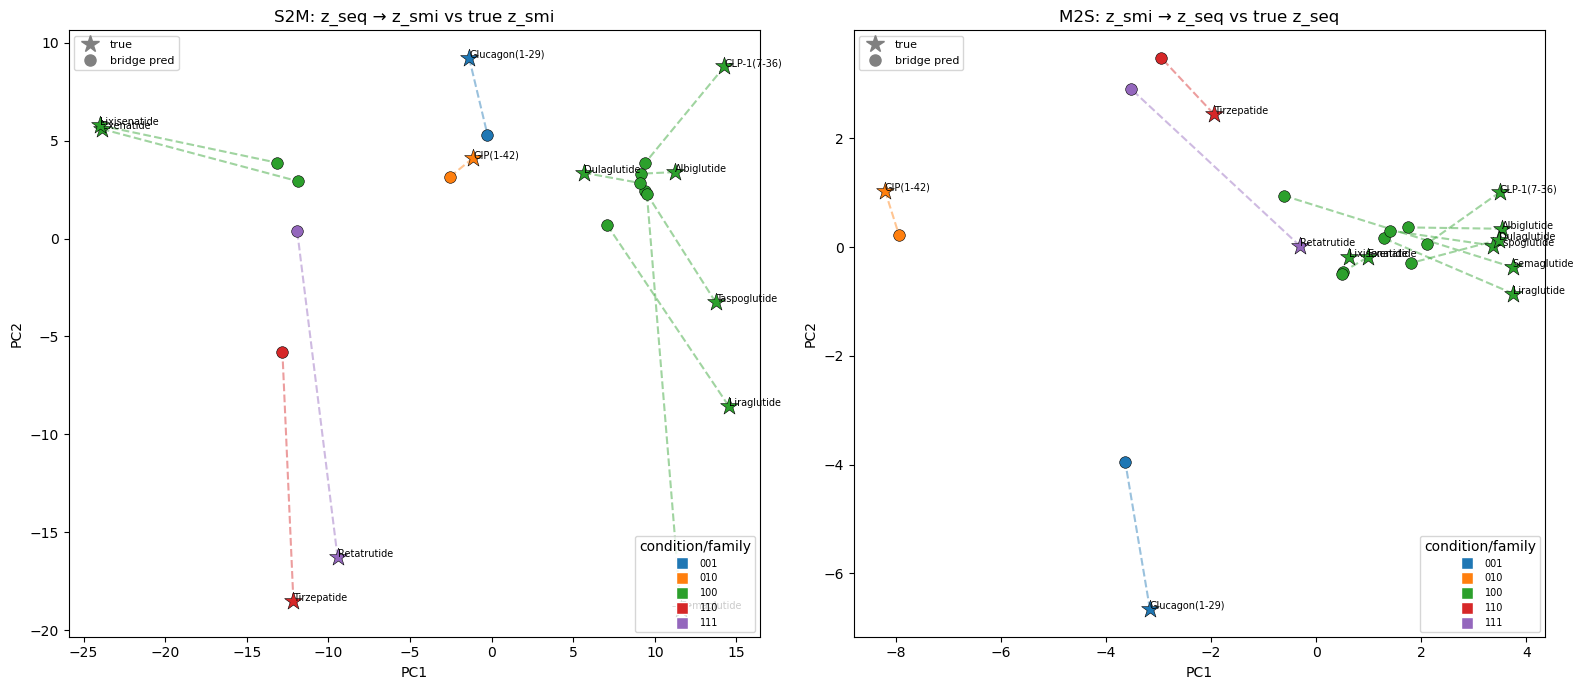

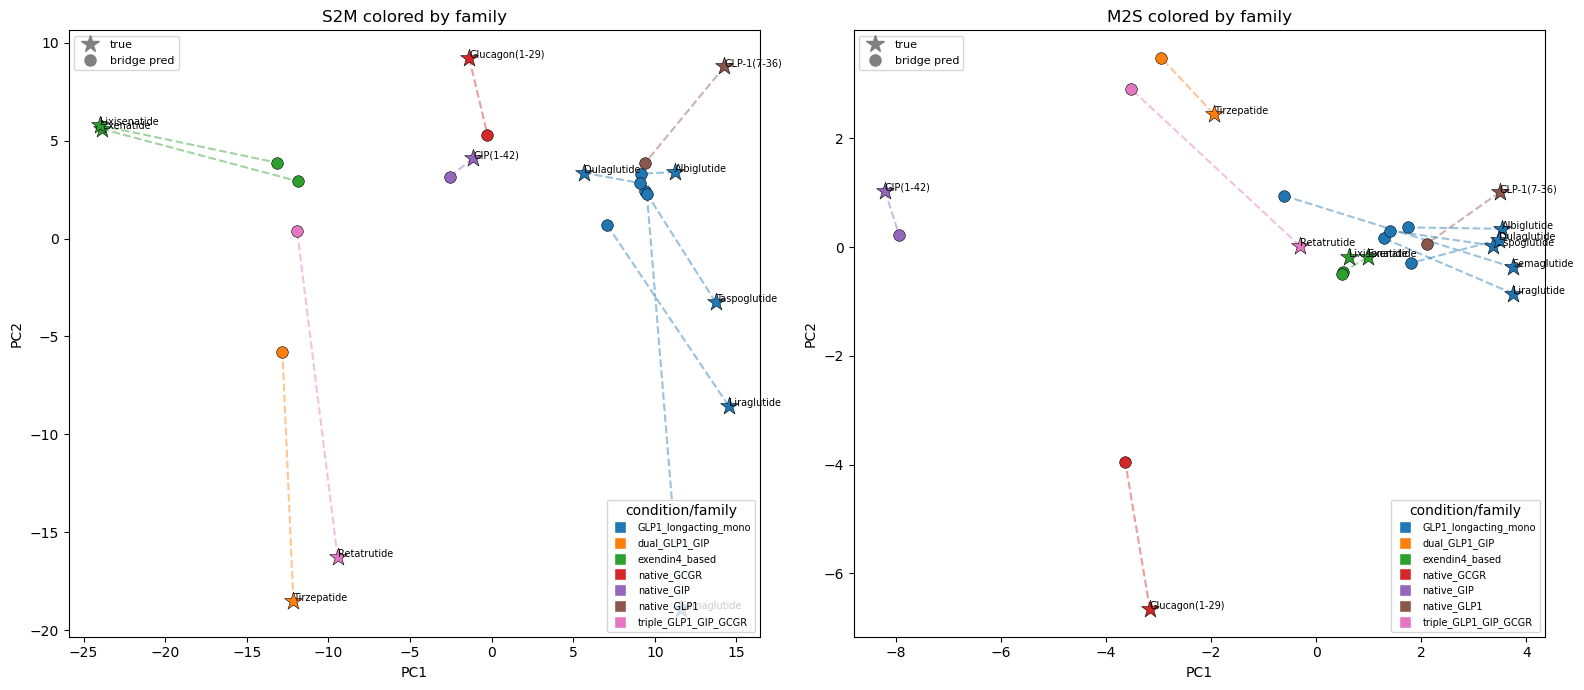

In [10]:
from matplotlib.lines import Line2D

def scatter_true_pred(ax, true_mat, pred_mat, names, color_labels, title):
    combined = np.vstack([true_mat, pred_mat])
    xy = PCA(n_components=2, random_state=SEED).fit_transform(combined)
    n = len(true_mat)
    true_xy, pred_xy = xy[:n], xy[n:]
    uniq = sorted(set(color_labels))
    cmap = plt.get_cmap('tab10')
    colors = {u: cmap(i % 10) for i, u in enumerate(uniq)}
    for i in range(n):
        col = colors[color_labels[i]]
        ax.scatter(true_xy[i,0], true_xy[i,1], marker='*', s=180, color=col, edgecolor='k', linewidth=0.4, zorder=3)
        ax.scatter(pred_xy[i,0], pred_xy[i,1], marker='o', s=70, color=col, edgecolor='k', linewidth=0.4, zorder=3)
        ax.plot([true_xy[i,0], pred_xy[i,0]], [true_xy[i,1], pred_xy[i,1]], '--', color=col, alpha=0.45)
        if n <= 20:
            ax.text(true_xy[i,0], true_xy[i,1], str(names[i]), fontsize=7)
    ax.set_title(title)
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    handles = [Line2D([0],[0], marker='*', color='gray', linestyle='None', markersize=13, label='true'),
               Line2D([0],[0], marker='o', color='gray', linestyle='None', markersize=8, label='bridge pred')]
    leg1 = ax.legend(handles=handles, loc='upper left', fontsize=8)
    ax.add_artist(leg1)
    cond_handles = [Line2D([0],[0], marker='s', color='w', markerfacecolor=colors[u], markersize=9, label=u) for u in uniq]
    ax.legend(handles=cond_handles, title='condition/family', loc='lower right', fontsize=7)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
scatter_true_pred(axes[0], Z_smi[te_idx], s2m_pred_te, names_all[te_idx], cond_all[te_idx], 'S2M: z_seq → z_smi vs true z_smi')
scatter_true_pred(axes[1], Z_seq[te_idx], m2s_pred_te, names_all[te_idx], cond_all[te_idx], 'M2S: z_smi → z_seq vs true z_seq')
plt.tight_layout()
plt.savefig(FIG_DIR / 'pca_true_vs_bridge_test_condition.png', dpi=220, bbox_inches='tight')
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
scatter_true_pred(axes[0], Z_smi[te_idx], s2m_pred_te, names_all[te_idx], family_all[te_idx], 'S2M colored by family')
scatter_true_pred(axes[1], Z_seq[te_idx], m2s_pred_te, names_all[te_idx], family_all[te_idx], 'M2S colored by family')
plt.tight_layout()
plt.savefig(FIG_DIR / 'pca_true_vs_bridge_test_family.png', dpi=220, bbox_inches='tight')
plt.show()


# Tier 2 — Decoder-based interpretation and residual analysis


## 10. Load SMILES decoder

SMILES decoder를 로드해서 latent-only 지표의 한계를 보완합니다.

기본 설정은 `sample`입니다. 다만 `sample_best`는 여러 후보 중 target Tanimoto가 가장 높은 것을 고르므로, **생성 후보 upper-bound**로 해석해야 합니다. 발표 메인에는 greedy 또는 sample mean도 함께 보는 것이 안전합니다.


In [11]:
# ===== Load SMILES VAE metadata/checkpoint =====
_ckpt = torch.load(SMILES_CKPT_PATH, map_location=DEVICE)
if isinstance(_ckpt, dict) and 'state_dict' in _ckpt:
    smi_state = _ckpt['state_dict']
    smi_meta = _ckpt.get('metadata', None)
else:
    smi_state = _ckpt
    smi_meta = None
if smi_meta is None:
    with open(SMILES_META_PATH, 'r', encoding='utf-8') as f:
        smi_meta = json.load(f)

tok = smi_meta['tokenizer']
VOCAB_SIZE = int(tok['vocab_size'])
MAX_LEN = int(tok['max_len'])
PAD_IDX, SOS_IDX = int(tok['pad_idx']), int(tok['sos_idx'])
EOS_IDX, UNK_IDX = int(tok['eos_idx']), int(tok['unk_idx'])
bpe_c2i = dict(tok['bpe_c2i'])
bpe_i2c = {int(k): v for k, v in tok['bpe_i2c'].items()}
bpe_merges = {}
for k, v in tok.get('bpe_merges', {}).items():
    a, b = k.split('\x00')
    bpe_merges[(a, b)] = v

fp_meta = smi_meta['fingerprint']
N_BITS_MG = int(fp_meta.get('n_bits_mg', fp_meta.get('n_bits', 1024)))
RADIUS = int(fp_meta['radius'])
cond_meta = smi_meta['condition']
COND_LABELS = cond_meta['cond_labels']
N_COND = int(cond_meta['n_cond'])
model_meta = smi_meta['model']
EMB_DIM = int(model_meta['emb_dim'])
LATENT_DIM = int(model_meta['latent_dim'])
DROPOUT = float(model_meta.get('dropout', 0.1))
DEC_GRU_DIM = int(model_meta.get('dec_gru_dim', 128))
DEC_N_LAYERS = int(model_meta.get('dec_n_layers', 1))

print('SMILES decoder metadata:', {'vocab': VOCAB_SIZE, 'max_len': MAX_LEN, 'latent': LATENT_DIM, 'cond_labels': COND_LABELS})

class GRUSELFIESDecoder(nn.Module):
    def __init__(self):
        super().__init__()
        gru_in = EMB_DIM + LATENT_DIM + N_COND
        self.fc_init = nn.Linear(LATENT_DIM + N_COND, DEC_GRU_DIM * DEC_N_LAYERS)
        self.token_emb = nn.Embedding(VOCAB_SIZE, EMB_DIM, padding_idx=PAD_IDX)
        self.gru = nn.GRU(gru_in, DEC_GRU_DIM, num_layers=DEC_N_LAYERS, batch_first=True)
        self.dropout = nn.Dropout(DROPOUT)
        self.fc_out = nn.Linear(DEC_GRU_DIM, VOCAB_SIZE)
    def _init_hidden(self, z, cond):
        h = torch.tanh(self.fc_init(torch.cat([z, cond], dim=-1)))
        B = z.size(0)
        return h.view(B, DEC_N_LAYERS, DEC_GRU_DIM).permute(1, 0, 2).contiguous()
    @torch.no_grad()
    def greedy(self, z, cond, max_len=None):
        if max_len is None: max_len = MAX_LEN
        B = z.size(0)
        h = self._init_hidden(z, cond)
        token = torch.full((B,1), SOS_IDX, dtype=torch.long, device=z.device)
        gen_ids = [[] for _ in range(B)]
        finished = torch.zeros(B, dtype=torch.bool, device=z.device)
        for _ in range(max_len):
            emb = self.token_emb(token)
            inp = torch.cat([emb, z.unsqueeze(1), cond.unsqueeze(1)], dim=-1)
            out, h = self.gru(inp, h)
            logits = self.fc_out(out.squeeze(1))
            logits[:, UNK_IDX] = -1e9
            nxt = logits.argmax(dim=-1)
            for b in range(B):
                if not finished[b]:
                    t = int(nxt[b].item())
                    gen_ids[b].append(t)
                    if t == EOS_IDX:
                        finished[b] = True
            if finished.all(): break
            nxt = torch.where(finished, torch.full_like(nxt, PAD_IDX), nxt)
            token = nxt.unsqueeze(1)
        return gen_ids[0] if B == 1 else gen_ids
    @torch.no_grad()
    def sample(self, z, cond, max_len=None, temperature=0.8, top_k=20, top_p=0.9, repetition_penalty=1.2, min_len=30, eos_boost=0.005):
        if max_len is None: max_len = MAX_LEN
        B = z.size(0)
        h = self._init_hidden(z, cond)
        token = torch.full((B,1), SOS_IDX, dtype=torch.long, device=z.device)
        gen_ids = [[] for _ in range(B)]
        finished = torch.zeros(B, dtype=torch.bool, device=z.device)
        for step in range(max_len):
            emb = self.token_emb(token)
            inp = torch.cat([emb, z.unsqueeze(1), cond.unsqueeze(1)], dim=-1)
            out, h = self.gru(inp, h)
            logits = self.fc_out(out.squeeze(1))
            logits[:, UNK_IDX] = -1e9
            logits[:, PAD_IDX] = -1e9
            if step < min_len:
                logits[:, EOS_IDX] = -1e9
            else:
                logits[:, EOS_IDX] += eos_boost * (step - min_len)
            logits = logits / max(temperature, 1e-6)
            if repetition_penalty and repetition_penalty > 1.0:
                for b in range(B):
                    if finished[b]: continue
                    for tid in set(gen_ids[b][-8:]):
                        val = logits[b, tid]
                        logits[b, tid] = val / repetition_penalty if val > 0 else val * repetition_penalty
            if top_k and top_k > 0:
                k = min(top_k, logits.size(-1))
                kth = torch.topk(logits, k, dim=-1).values[:, -1].unsqueeze(-1)
                logits = torch.where(logits < kth, torch.full_like(logits, -1e9), logits)
            if top_p and top_p < 1.0:
                sorted_logits, sorted_idx = torch.sort(logits, descending=True, dim=-1)
                sorted_probs = torch.softmax(sorted_logits, dim=-1)
                cum_probs = torch.cumsum(sorted_probs, dim=-1)
                remove = cum_probs > top_p
                remove[:, 1:] = remove[:, :-1].clone()
                remove[:, 0] = False
                sorted_logits = sorted_logits.masked_fill(remove, -1e9)
                logits = torch.full_like(logits, -1e9)
                logits.scatter_(1, sorted_idx, sorted_logits)
            probs = torch.softmax(logits, dim=-1)
            nxt = torch.multinomial(probs, num_samples=1).squeeze(1)
            for b in range(B):
                if finished[b]: continue
                t = int(nxt[b].item())
                gen_ids[b].append(t)
                if t == EOS_IDX:
                    finished[b] = True
            if finished.all(): break
            nxt = torch.where(finished, torch.full_like(nxt, PAD_IDX), nxt)
            token = nxt.unsqueeze(1)
        cleaned = []
        for ids in gen_ids:
            seq = []
            for tid in ids:
                if tid == EOS_IDX: break
                if tid not in (PAD_IDX, SOS_IDX): seq.append(tid)
            cleaned.append(seq)
        return cleaned[0] if B == 1 else cleaned

smi_decoder = GRUSELFIESDecoder().to(DEVICE)
dec_state = {k[len('smi_decoder.'):]: v for k, v in smi_state.items() if k.startswith('smi_decoder.')}
missing, unexpected = smi_decoder.load_state_dict(dec_state, strict=False)
smi_decoder.eval()
print('smi_decoder params:', len(dec_state))
print('missing:', missing)
print('unexpected:', unexpected)
if len(dec_state) == 0 or len(missing) > 0:
    raise RuntimeError('SMILES decoder weight load failed. Check checkpoint/model structure.')


SMILES decoder metadata: {'vocab': 250, 'max_len': 116, 'latent': 128, 'cond_labels': ['GLP1', 'GCGR', 'GIP']}
smi_decoder params: 9
missing: []
unexpected: []


## 11. SMILES decode helpers


In [12]:
def condition_for_smiles_model(GLP1R, GIPR, GCGR):
    out = []
    for lab in COND_LABELS:
        key = str(lab).upper().replace('_','').replace('-','')
        if key in ('GLP1','GLP1R'):
            out.append(float(GLP1R))
        elif key in ('GIP','GIPR'):
            out.append(float(GIPR))
        elif key in ('GCGR','GCG','GLUCAGON'):
            out.append(float(GCGR))
        else:
            raise ValueError(f'Unknown condition label: {lab}')
    return out

def canonicalize_smiles(smi):
    mol = Chem.MolFromSmiles(str(smi))
    if mol is None:
        return None
    return Chem.MolToSmiles(mol, canonical=True, isomericSmiles=False)

def ids_to_smiles_dec(ids):
    toks = []
    for i in ids:
        i = int(i)
        if i == EOS_IDX:
            break
        if i in (PAD_IDX, SOS_IDX, UNK_IDX):
            continue
        toks.append(bpe_i2c.get(i, ''))
    sf_str = ''.join(toks)
    try:
        smi = sf.decoder(sf_str)
    except Exception:
        return None
    return canonicalize_smiles(smi) if smi else None

def tanimoto(s1, s2):
    if not s1 or not s2:
        return np.nan
    m1, m2 = Chem.MolFromSmiles(str(s1)), Chem.MolFromSmiles(str(s2))
    if m1 is None or m2 is None:
        return np.nan
    f1 = AllChem.GetMorganFingerprintAsBitVect(m1, RADIUS, nBits=N_BITS_MG)
    f2 = AllChem.GetMorganFingerprintAsBitVect(m2, RADIUS, nBits=N_BITS_MG)
    return float(DataStructs.TanimotoSimilarity(f1, f2))

def mol_props(smi):
    mol = Chem.MolFromSmiles(str(smi)) if smi else None
    if mol is None:
        return {'valid': False, 'MW': np.nan, 'LogP': np.nan, 'TPSA': np.nan, 'amide': np.nan, 'alkyl_proxy': np.nan}
    patt = Chem.MolFromSmarts('C(=O)N')
    amide = len(mol.GetSubstructMatches(patt))
    # simple proxy: non-aromatic aliphatic carbon count
    alkyl = 0
    for atom in mol.GetAtoms():
        if atom.GetAtomicNum() == 6 and not atom.GetIsAromatic():
            if all(b.GetBondTypeAsDouble() == 1.0 for b in atom.GetBonds()):
                alkyl += 1
    return {
        'valid': True,
        'MW': float(Descriptors.MolWt(mol)),
        'LogP': float(Descriptors.MolLogP(mol)),
        'TPSA': float(rdMolDescriptors.CalcTPSA(mol)),
        'amide': int(amide),
        'alkyl_proxy': int(alkyl),
    }

DECODE_METHOD = 'sample'   # 'greedy' or 'sample'
N_DECODE_SAMPLES = 20      # sample일 때 후보 수. 발표용 best-of-N은 upper-bound로 해석.
SAMPLE_KW = dict(temperature=0.8, top_k=20, top_p=0.90, repetition_penalty=1.2, min_len=30, eos_boost=0.005)

@torch.no_grad()
def decode_candidates_from_raw_z(z_raw, cond_bridge_order, method=DECODE_METHOD, n_samples=N_DECODE_SAMPLES):
    z = torch.tensor(np.asarray(z_raw, dtype='float32').reshape(1, -1), dtype=torch.float32, device=DEVICE)
    cond_smiles = condition_for_smiles_model(*[int(x) for x in cond_bridge_order])
    c = torch.tensor([cond_smiles], dtype=torch.float32, device=DEVICE)
    ids_list = []
    if method == 'greedy':
        ids_list = [smi_decoder.greedy(z, c)]
    elif method == 'sample':
        for _ in range(n_samples):
            ids_list.append(smi_decoder.sample(z, c, **SAMPLE_KW))
    else:
        raise ValueError('method must be greedy or sample')
    smis = [ids_to_smiles_dec(ids) for ids in ids_list]
    # unique preserving order
    out, seen = [], set()
    for smi in smis:
        if smi is not None and smi not in seen:
            out.append(smi); seen.add(smi)
    return out

def summarize_decode_against_target(z_raw, cond, target_smi, prefix, method=DECODE_METHOD):
    cands = decode_candidates_from_raw_z(z_raw, cond, method=method)
    tanis = [tanimoto(s, target_smi) for s in cands]
    valid_tanis = [t for t in tanis if not np.isnan(t)]
    if valid_tanis:
        best_idx = int(np.nanargmax(tanis))
        best_smi = cands[best_idx]
        best_tani = float(tanis[best_idx])
        mean_tani = float(np.nanmean(tanis))
        first_tani = float(tanis[0]) if len(tanis) and not np.isnan(tanis[0]) else np.nan
    else:
        best_smi, best_tani, mean_tani, first_tani = None, np.nan, np.nan, np.nan
    row = {
        f'{prefix}_n_unique': len(cands),
        f'{prefix}_valid': len(cands) > 0,
        f'{prefix}_tani_first': first_tani,
        f'{prefix}_tani_mean': mean_tani,
        f'{prefix}_tani_best': best_tani,
        f'{prefix}_best_smiles': (best_smi or '')[:80],
    }
    return row


## 12. SMILES decoder validation and Tanimoto gap

비교 대상:

- `true_z_decode`: 원래 SMILES VAE latent를 decode한 결과. SMILES decoder 자체의 upper-bound/sanity check.
- `S2M_direct`: `z_seq → S2M → z_smi_pred → SMILES decode`.
- `SMI_SEQ_SMI_cycle`: `z_smi → M2S → z_seq_pred → S2M → z_smi_cycle → SMILES decode`.

`gap = true_z_decode - S2M_direct`가 크면, decoder가 아니라 Bridge mapping에서 구조 정보가 손실된 것으로 해석할 수 있습니다.


In [13]:
@torch.no_grad()
def s2m_from_scaled_zseq(zseq_scaled, cond):
    z = torch.tensor(np.asarray(zseq_scaled, dtype='float32').reshape(1, -1), device=DEVICE)
    c = torch.tensor(np.asarray(cond, dtype='float32').reshape(1, -1), device=DEVICE)
    return bridge_s2m(z, c).cpu().numpy()[0]

@torch.no_grad()
def m2s_from_scaled_zsmi(zsmi_scaled, cond):
    z = torch.tensor(np.asarray(zsmi_scaled, dtype='float32').reshape(1, -1), device=DEVICE)
    c = torch.tensor(np.asarray(cond, dtype='float32').reshape(1, -1), device=DEVICE)
    return bridge_m2s(z, c).cpu().numpy()[0]

decode_rows = []
for pos, idx in enumerate(te_idx):
    name = names_all[idx]
    target_smi = str(latent_df.iloc[idx]['smiles'])
    cond = C_raw[idx]
    # true raw z_smi
    z_true_raw = Z_smi_raw[idx]
    # S2M direct raw z_smi
    z_s2m_scaled = s2m_pred_te[pos]
    z_s2m_raw = smi_scaler.inverse_transform(z_s2m_scaled.reshape(1, -1))[0]
    # full cycle raw z_smi: z_smi -> M2S -> S2M
    z_m2s_scaled = m2s_pred_te[pos]
    z_cycle_scaled = s2m_from_scaled_zseq(z_m2s_scaled, cond)
    z_cycle_raw = smi_scaler.inverse_transform(z_cycle_scaled.reshape(1, -1))[0]

    row = {
        'name': name,
        'condition': cond_all[idx],
        'family': family_label(name),
        'target_smiles_prefix': target_smi[:80],
    }
    row.update(summarize_decode_against_target(z_true_raw, cond, target_smi, 'true_z'))
    row.update(summarize_decode_against_target(z_s2m_raw, cond, target_smi, 'S2M'))
    row.update(summarize_decode_against_target(z_cycle_raw, cond, target_smi, 'cycle'))
    row['gap_best_true_minus_S2M'] = row['true_z_tani_best'] - row['S2M_tani_best']
    row['gap_mean_true_minus_S2M'] = row['true_z_tani_mean'] - row['S2M_tani_mean']
    decode_rows.append(row)

decode_df = pd.DataFrame(decode_rows)
decode_df.to_csv(TAB_DIR / 'smiles_decode_tanimoto_gap_test.csv', index=False)
display(decode_df[['name','family','true_z_tani_mean','true_z_tani_best','S2M_tani_mean','S2M_tani_best','cycle_tani_mean','cycle_tani_best','gap_mean_true_minus_S2M','gap_best_true_minus_S2M']])

summary_cols = ['true_z_tani_mean','true_z_tani_best','S2M_tani_mean','S2M_tani_best','cycle_tani_mean','cycle_tani_best']
print(decode_df[summary_cols].mean(numeric_only=True))


,name,family,true_z_tani_mean,true_z_tani_best,S2M_tani_mean,S2M_tani_best,cycle_tani_mean,cycle_tani_best,gap_mean_true_minus_S2M,gap_best_true_minus_S2M
0,GLP-1(7-36),native_GLP1,0.525259,0.638814,0.577195,1.000000,0.512813,0.626984,-0.051936,-0.361186
1,GIP(1-42),native_GIP,0.645307,1.000000,0.649012,1.000000,0.767829,1.000000,-0.003705,0.000000
2,Glucagon(1-29),native_GCGR,0.718721,1.000000,0.727366,1.000000,0.737412,1.000000,-0.008645,0.000000
3,Exenatide,exendin4_based,0.874277,1.000000,0.653979,1.000000,0.766430,1.000000,0.220298,0.000000
4,Lixisenatide,exendin4_based,0.947522,0.947522,0.640261,0.947522,0.770059,0.947522,0.307261,0.000000
5,Liraglutide,GLP1_longacting_mono,0.703838,0.833828,0.677678,1.000000,0.645899,0.833828,0.026160,-0.166172
6,Albiglutide,GLP1_longacting_mono,0.662928,0.933333,0.622620,0.888889,0.662312,0.798799,0.040308,0.044444
7,Taspoglutide,GLP1_longacting_mono,0.610723,0.922581,0.677910,0.881988,0.648577,0.856322,-0.067187,0.040593
8,Dulaglutide,GLP1_longacting_mono,0.604029,0.774390,0.603382,0.797619,0.598706,0.796238,0.000647,-0.023229
9,Semaglutide,GLP1_longacting_mono,0.742093,1.000000,0.596371,0.954416,0.682568,0.930556,0.145722,0.045584


true_z_tani_mean    0.712469
true_z_tani_best    0.920872
S2M_tani_mean       0.642088
S2M_tani_best       0.955869
cycle_tani_mean     0.675993
cycle_tani_best     0.899187
dtype: float64


## 13. Modification residual analysis

`true z_smi - S2M(z_seq)`는 sequence latent로 설명되지 않는 chemical residual로 볼 수 있습니다. 

이 값이 큰 약물은 lipidation, linker, Aib, dual/triple 설계 등 sequence-only representation이 놓치기 쉬운 요소를 가질 가능성이 큽니다.


,name,condition,family,s2m_residual_l2_scaled,s2m_residual_mse_scaled,s2m_cos,modification_note,retrieval_top1,retrieval_self_rank,true_z_tani_mean,S2M_tani_mean,cycle_tani_mean,gap_mean_true_minus_S2M,true_z_tani_best,S2M_tani_best,gap_best_true_minus_S2M
9,Semaglutide,100,GLP1_longacting_mono,21.828192,3.722422,0.543559,GLP-1 analog with Aib + linker + C18 fatty-aci...,Taspoglutide,6,0.742093,0.596371,0.682568,0.145722,1.000000,0.954416,0.045584
11,Retatrutide,111,triple_GLP1_GIP_GCGR,19.341801,2.922697,0.674628,triple GLP-1/GIP/GCGR agonist with lipidation,Exenatide,4,0.806940,0.668684,0.660529,0.138255,1.000000,1.000000,0.000000
10,Tirzepatide,110,dual_GLP1_GIP,13.707501,1.467934,0.897646,dual GLP-1/GIP agonist with lipidation,Tirzepatide,1,0.707989,0.610595,0.658778,0.097394,1.000000,1.000000,0.000000
3,Exenatide,100,exendin4_based,12.778437,1.275691,0.961415,exendin-4 based peptide; sequence family diffe...,Exenatide,1,0.874277,0.653979,0.766430,0.220298,1.000000,1.000000,0.000000
5,Liraglutide,100,GLP1_longacting_mono,12.468561,1.214570,0.852801,GLP-1 analog with fatty-acid/lipidation modifi...,Taspoglutide,2,0.703838,0.677678,0.645899,0.026160,0.833828,1.000000,-0.166172
4,Lixisenatide,100,exendin4_based,12.139322,1.151274,0.983641,exendin-4 based analog; C-terminal extension,Exenatide,2,0.947522,0.640261,0.770059,0.307261,0.947522,0.947522,0.000000
0,GLP-1(7-36),100,native_GLP1,11.974721,1.120265,0.840410,native peptide; no major long-acting modification,GLP-1(7-36),1,0.525259,0.577195,0.512813,-0.051936,0.638814,1.000000,-0.361186
8,Dulaglutide,100,GLP1_longacting_mono,11.063677,0.956289,0.758468,GLP-1 analog with Fc/fusion-style long acting ...,Albiglutide,4,0.604029,0.603382,0.598706,0.000647,0.774390,0.797619,-0.023229
7,Taspoglutide,100,GLP1_longacting_mono,9.150420,0.654142,0.854337,GLP-1 analog with Aib-like stabilization; fail...,Taspoglutide,1,0.610723,0.677910,0.648577,-0.067187,0.922581,0.881988,0.040593
6,Albiglutide,100,GLP1_longacting_mono,8.497673,0.564144,0.848318,GLP-1 dimer/fusion-style long acting design,Albiglutide,1,0.662928,0.622620,0.662312,0.040308,0.933333,0.888889,0.044444


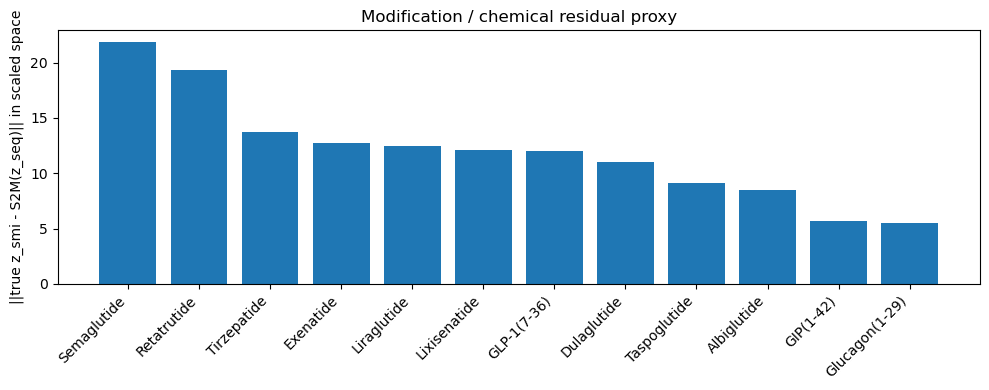

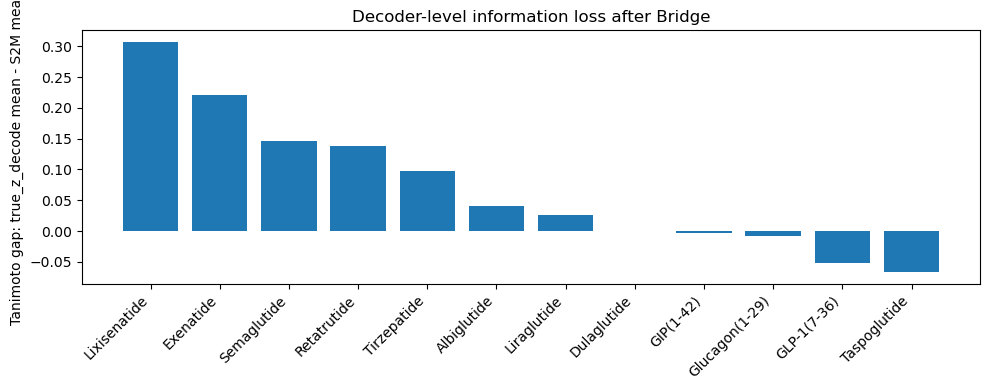

In [14]:
modification_note = {
    'GLP-1(7-36)': 'native peptide; no major long-acting modification',
    'GIP(1-42)': 'native GIP peptide',
    'Glucagon(1-29)': 'native glucagon peptide',
    'Exenatide': 'exendin-4 based peptide; sequence family differs from GLP-1',
    'Lixisenatide': 'exendin-4 based analog; C-terminal extension',
    'Liraglutide': 'GLP-1 analog with fatty-acid/lipidation modification',
    'Albiglutide': 'GLP-1 dimer/fusion-style long acting design',
    'Taspoglutide': 'GLP-1 analog with Aib-like stabilization; failed branch',
    'Dulaglutide': 'GLP-1 analog with Fc/fusion-style long acting design',
    'Semaglutide': 'GLP-1 analog with Aib + linker + C18 fatty-acid lipidation',
    'Tirzepatide': 'dual GLP-1/GIP agonist with lipidation',
    'Retatrutide': 'triple GLP-1/GIP/GCGR agonist with lipidation',
}

residual_rows = []
for pos, idx in enumerate(te_idx):
    name = names_all[idx]
    pred = s2m_pred_te[pos]
    true = Z_smi[idx]
    row = {
        'name': name,
        'condition': cond_all[idx],
        'family': family_label(name),
        's2m_residual_l2_scaled': float(np.linalg.norm(true - pred)),
        's2m_residual_mse_scaled': float(np.mean(np.square(true - pred))),
        's2m_cos': float(cosine_rows(pred.reshape(1,-1), true.reshape(1,-1))[0]),
        'modification_note': modification_note.get(name, ''),
    }
    # attach retrieval rank/top1
    match = nn_s2m_test[nn_s2m_test['query'] == name]
    if len(match):
        row['retrieval_top1'] = match.iloc[0]['top1']
        row['retrieval_self_rank'] = match.iloc[0]['self_rank']
    # attach Tanimoto gap if available
    dmatch = decode_df[decode_df['name'] == name]
    if len(dmatch):
        for col in ['true_z_tani_mean','S2M_tani_mean','cycle_tani_mean','gap_mean_true_minus_S2M','true_z_tani_best','S2M_tani_best','gap_best_true_minus_S2M']:
            row[col] = dmatch.iloc[0][col]
    residual_rows.append(row)

residual_df = pd.DataFrame(residual_rows).sort_values('s2m_residual_l2_scaled', ascending=False)
residual_df.to_csv(TAB_DIR / 'modification_residual_analysis_test.csv', index=False)
display(residual_df)

plt.figure(figsize=(10, 4))
plt.bar(residual_df['name'], residual_df['s2m_residual_l2_scaled'])
plt.xticks(rotation=45, ha='right')
plt.ylabel('||true z_smi - S2M(z_seq)|| in scaled space')
plt.title('Modification / chemical residual proxy')
plt.tight_layout()
plt.savefig(FIG_DIR / 'modification_residual_l2_test.png', dpi=220, bbox_inches='tight')
plt.show()

if 'gap_mean_true_minus_S2M' in residual_df.columns:
    plt.figure(figsize=(10, 4))
    tmp = residual_df.sort_values('gap_mean_true_minus_S2M', ascending=False)
    plt.bar(tmp['name'], tmp['gap_mean_true_minus_S2M'])
    plt.xticks(rotation=45, ha='right')
    plt.ylabel('Tanimoto gap: true_z_decode mean - S2M mean')
    plt.title('Decoder-level information loss after Bridge')
    plt.tight_layout()
    plt.savefig(FIG_DIR / 'tanimoto_gap_true_minus_s2m_test.png', dpi=220, bbox_inches='tight')
    plt.show()


## 14. Load sequence decoder and run M2S sequence sanity check

`z_smi → M2S → z_seq_pred → sequence decode`를 확인합니다. Exact reconstruction보다는 family-level sanity check로 보는 것이 안전합니다.


In [15]:
class ConditionalSequenceVAEAux(nn.Module):
    def __init__(self, vocab_size, max_len, pad_idx, condition_dim=3, embed_dim=64, hidden_dim=128, latent_dim=32, cond_hidden_dim=32, dropout=0.2):
        super().__init__()
        self.vocab_size = vocab_size
        self.max_len = max_len
        self.pad_idx = pad_idx
        self.latent_dim = latent_dim
        self.condition_dim = condition_dim
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.pos_embedding = nn.Embedding(max_len, embed_dim)
        self.cond_encoder = nn.Sequential(nn.Linear(condition_dim, cond_hidden_dim), nn.ReLU(), nn.Dropout(dropout))
        self.encoder_cnn = nn.Sequential(
            nn.Conv1d(embed_dim, hidden_dim, kernel_size=3, padding=1), nn.ReLU(), nn.Dropout(dropout),
            nn.Conv1d(hidden_dim, hidden_dim, kernel_size=3, padding=1), nn.ReLU(), nn.Dropout(dropout),
        )
        self.fc_mu = nn.Linear(hidden_dim + cond_hidden_dim, latent_dim)
        self.fc_logvar = nn.Linear(hidden_dim + cond_hidden_dim, latent_dim)
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim + cond_hidden_dim, hidden_dim), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim * 2), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden_dim * 2, max_len * vocab_size),
        )
        self.condition_classifier = nn.Sequential(nn.Linear(latent_dim, 64), nn.ReLU(), nn.Dropout(dropout), nn.Linear(64, condition_dim))
    def encode(self, x, c):
        B, L = x.size()
        pos = torch.arange(L, device=x.device).unsqueeze(0).expand(B, L)
        h = self.embedding(x) + self.pos_embedding(pos)
        h = self.encoder_cnn(h.transpose(1,2)).mean(dim=2)
        c_emb = self.cond_encoder(c)
        h = torch.cat([h, c_emb], dim=1)
        return self.fc_mu(h), self.fc_logvar(h)
    def decode(self, z, c):
        c_emb = self.cond_encoder(c)
        logits = self.decoder(torch.cat([z, c_emb], dim=1))
        return logits.view(-1, self.max_len, self.vocab_size)

seq_ckpt = torch.load(SEQ_CKPT_PATH, map_location=DEVICE)
seq_vocab = seq_ckpt['vocab']
seq_stoi = seq_ckpt['stoi']
seq_itos = seq_ckpt['itos']
seq_max_len = seq_ckpt['max_len']
seq_config = seq_ckpt.get('config', {})
SEQ_PAD, SEQ_SOS, SEQ_EOS = '<PAD>', '<SOS>', '<EOS>'
seq_pad_idx = seq_stoi[SEQ_PAD]
sequence_model = ConditionalSequenceVAEAux(
    vocab_size=len(seq_vocab), max_len=seq_max_len, pad_idx=seq_pad_idx,
    condition_dim=3,
    embed_dim=seq_config.get('embed_dim', 64),
    hidden_dim=seq_config.get('hidden_dim', 128),
    latent_dim=seq_config.get('latent_dim', 32),
    cond_hidden_dim=seq_config.get('cond_hidden_dim', 32),
    dropout=seq_config.get('dropout', 0.2),
).to(DEVICE)
state = seq_ckpt['model_state_dict'] if 'model_state_dict' in seq_ckpt else seq_ckpt
sequence_model.load_state_dict(state, strict=False)
sequence_model.eval()
inv_stoi = {v:k for k,v in seq_stoi.items()}
print('Sequence decoder loaded.')

def ids_to_seq(ids):
    out = []
    for i in ids:
        ch = inv_stoi.get(int(i), '')
        if ch == SEQ_SOS: continue
        if ch == SEQ_EOS: break
        if ch == SEQ_PAD: continue
        out.append(ch)
    return ''.join(out)

@torch.no_grad()
def decode_seq_from_scaled_z(z_seq_scaled_row, cond_row):
    z_raw = seq_scaler.inverse_transform(np.asarray(z_seq_scaled_row).reshape(1,-1)).astype('float32')
    z = torch.tensor(z_raw, dtype=torch.float32, device=DEVICE)
    c = torch.tensor(np.asarray(cond_row, dtype='float32').reshape(1,-1), dtype=torch.float32, device=DEVICE)
    logits = sequence_model.decode(z, c)
    ids = logits.argmax(-1).squeeze(0).cpu().numpy()
    return ids_to_seq(ids)

def token_acc(a, b):
    n = min(len(a), len(b))
    return float(sum(x == y for x,y in zip(a,b)) / n) if n else 0.0

seq_rows = []
for pos, idx in enumerate(te_idx):
    true_seq = str(latent_df.iloc[idx]['sequence'])
    dec = decode_seq_from_scaled_z(m2s_pred_te[pos], C_raw[idx])
    seq_rows.append({
        'name': names_all[idx],
        'family': family_label(names_all[idx]),
        'decoded_prefix': dec[:60],
        'true_prefix': true_seq[:60],
        'decoded_len': len(dec),
        'true_len': len(true_seq),
        'tok_acc': token_acc(dec, true_seq),
        'exact': dec == true_seq,
    })
seq_decode_df = pd.DataFrame(seq_rows)
seq_decode_df.to_csv(TAB_DIR / 'm2s_sequence_decode_sanity_test.csv', index=False)
display(seq_decode_df)
print('mean tok_acc:', seq_decode_df['tok_acc'].mean(), 'exact rate:', seq_decode_df['exact'].mean())


Sequence decoder loaded.


,name,family,decoded_prefix,true_prefix,decoded_len,true_len,tok_acc,exact
0,GLP-1(7-36),native_GLP1,HAEGTFTSDVSSYLEGQAAKEFIAWLVKGR,HAEGTFTSDVSSYLEGQAAKEFIAWLVKGR,30,30,1.000000,True
1,GIP(1-42),native_GIP,YAEGTFISDYSIAMDKIRQQDFVNWLLAQKGKKNDWKHNITQ,YAEGTFISDYSIAMDKIHQQDFVNWLLAQKGKKNDWKHNITQ,42,42,0.976190,False
2,Glucagon(1-29),native_GCGR,HSQGTFTSDYSKYLDSRRAQDFVQWLMNT,HSQGTFTSDYSKYLDSRRAQDFVQWLMNT,29,29,1.000000,True
3,Exenatide,exendin4_based,HSEGTFTSDLSSYLEEQAAKEFVAWLVKGG,HGEGTFTSDLSKQMEEEAVRLFIEWLKNGGPSSGAPPPS,30,39,0.600000,False
4,Lixisenatide,exendin4_based,HSEGTFTSDLSSYLEEQAAKEFVAWLVKGG,HGEGTFTSDLSKQMEEEAVRLFIEWLKNGGPSSGAPPSKKKKKK,30,44,0.600000,False
5,Liraglutide,GLP1_longacting_mono,HAEGTFTSDVSSYLEGQAAKEFVAWLVKGR,HAEGTFTSDVSSYLEGQAAKEEFIAWLVRGRG,30,32,0.700000,False
6,Albiglutide,GLP1_longacting_mono,HAEGTFTSDVSSYLEGQAAKEFIAWLVKGR,HGEGTFTSDVSSYLEGQAAKEFIAWLVKGR,30,30,0.966667,False
7,Taspoglutide,GLP1_longacting_mono,HAEGTFTSDVSSYLEDQAAKEFVAWLKKGR,HXEGTFTSDVSSYLEGQAAKEFIAWLVKXR,30,30,0.833333,False
8,Dulaglutide,GLP1_longacting_mono,HAEGTFTSDVSSYLEGQAAKEFIAWLVKGR,HGEGTFTSDVSSYLEEQAAKEFIAWLVKGGG,30,31,0.900000,False
9,Semaglutide,GLP1_longacting_mono,HAEGTFTSDMSKYLDEQAAKEFVAWLINGK,HXEGTFTSDVSSYLEGQAAKEFIAWLVRGRG,30,31,0.700000,False


mean tok_acc: 0.8048534798534798 exact rate: 0.16666666666666666


# Tier 3 — Optional cross-modal disagreement diagnostics


## 15. Full cycle round-trip summary

이미 12번에서 full cycle decode도 계산했습니다. 여기서는 cycle이 direct S2M보다 나은지/나쁜지를 요약합니다.


In [16]:
cycle_summary = decode_df[['name','family','S2M_tani_mean','cycle_tani_mean','S2M_tani_best','cycle_tani_best']].copy()
cycle_summary['cycle_minus_S2M_mean'] = cycle_summary['cycle_tani_mean'] - cycle_summary['S2M_tani_mean']
cycle_summary['cycle_minus_S2M_best'] = cycle_summary['cycle_tani_best'] - cycle_summary['S2M_tani_best']
cycle_summary.to_csv(TAB_DIR / 'full_cycle_vs_direct_s2m_tanimoto.csv', index=False)
display(cycle_summary)
print(cycle_summary[['S2M_tani_mean','cycle_tani_mean','cycle_minus_S2M_mean']].mean(numeric_only=True))


,name,family,S2M_tani_mean,cycle_tani_mean,S2M_tani_best,cycle_tani_best,cycle_minus_S2M_mean,cycle_minus_S2M_best
0,GLP-1(7-36),native_GLP1,0.577195,0.512813,1.000000,0.626984,-0.064382,-0.373016
1,GIP(1-42),native_GIP,0.649012,0.767829,1.000000,1.000000,0.118817,0.000000
2,Glucagon(1-29),native_GCGR,0.727366,0.737412,1.000000,1.000000,0.010046,0.000000
3,Exenatide,exendin4_based,0.653979,0.766430,1.000000,1.000000,0.112451,0.000000
4,Lixisenatide,exendin4_based,0.640261,0.770059,0.947522,0.947522,0.129798,0.000000
5,Liraglutide,GLP1_longacting_mono,0.677678,0.645899,1.000000,0.833828,-0.031779,-0.166172
6,Albiglutide,GLP1_longacting_mono,0.622620,0.662312,0.888889,0.798799,0.039691,-0.090090
7,Taspoglutide,GLP1_longacting_mono,0.677910,0.648577,0.881988,0.856322,-0.029333,-0.025666
8,Dulaglutide,GLP1_longacting_mono,0.603382,0.598706,0.797619,0.796238,-0.004676,-0.001381
9,Semaglutide,GLP1_longacting_mono,0.596371,0.682568,0.954416,0.930556,0.086196,-0.023860


S2M_tani_mean           0.642088
cycle_tani_mean         0.675993
cycle_minus_S2M_mean    0.033905
dtype: float64


## 16. Cross-modal disagreement interpolation

같은 source→target 경로에서 두 경로를 비교합니다.

1. Sequence path: `z_seq(α) → S2M → z_smi_from_seq`
2. SMILES cycle path: `z_smi(α) → M2S → S2M → z_smi_from_smi`
3. Direct SMILES path: `z_smi(α)`

핵심 지표는 `z_smi_from_seq`와 `z_smi_from_smi` 사이의 distance/cosine입니다. 이 값이 크면 sequence와 SMILES가 말하는 변화 방향이 다르다는 뜻입니다.


,source,target,alpha,seq_vs_smi_cycle_l2,seq_vs_smi_cycle_cos,seq_vs_direct_smi_l2,cycle_vs_direct_smi_l2,SEQpath_valid_n,SEQpath_MW_mean,SEQpath_MW_std,...,Consensus_MW_mean,Consensus_MW_std,Consensus_LogP_mean,Consensus_LogP_std,Consensus_TPSA_mean,Consensus_TPSA_std,Consensus_amide_mean,Consensus_amide_std,Consensus_alkyl_proxy_mean,Consensus_alkyl_proxy_std
0,GLP-1(7-36),Semaglutide,0.0,5.120989,0.928711,11.974721,14.610878,5,3752.5914,339.487565,...,3453.4070,116.952540,-14.034410,0.468437,1433.3760,29.298742,31.20,0.748331,87.40,4.029888
1,GLP-1(7-36),Semaglutide,0.1,4.534080,0.944060,10.219271,12.271674,5,3408.6136,214.708223,...,3983.0838,491.113433,-13.771688,2.483413,1637.6820,210.766083,35.40,5.003998,104.20,14.076931
2,GLP-1(7-36),Semaglutide,0.2,3.881520,0.958875,9.078390,10.265758,5,3474.0472,180.408350,...,4118.5956,1085.828850,-16.577114,6.926951,1731.8760,492.566713,37.40,11.429786,106.60,25.827118
3,GLP-1(7-36),Semaglutide,0.3,3.390521,0.968462,8.767924,8.959148,5,3878.9464,444.989729,...,4133.9250,647.018288,-19.206862,5.786522,1756.0560,305.301687,38.60,6.280127,103.20,16.363374
4,GLP-1(7-36),Semaglutide,0.4,2.934870,0.976409,9.349482,8.742198,5,3514.5092,447.772619,...,4463.3768,1345.936607,-17.705512,6.805893,1872.7980,584.878889,40.60,12.483589,113.00,32.735302
5,GLP-1(7-36),Semaglutide,0.5,2.335546,0.985180,10.663279,9.825904,5,4020.1302,528.831527,...,3451.0098,142.340190,-13.586816,2.050065,1434.0420,69.424842,30.80,1.939072,87.80,4.534314
6,GLP-1(7-36),Semaglutide,0.6,2.459488,0.984337,12.470763,11.612033,5,3674.9836,297.623576,...,3645.6604,282.201727,-13.429290,1.129948,1505.4720,93.911809,32.80,2.227106,93.20,11.600000
7,GLP-1(7-36),Semaglutide,0.7,4.574956,0.955631,14.584670,13.620216,5,3579.5698,553.008858,...,3457.0380,121.927369,-13.327808,2.421896,1440.2480,60.880693,31.00,1.897367,89.40,5.425864
8,GLP-1(7-36),Semaglutide,0.8,8.093209,0.832461,16.888810,16.288129,5,4147.5084,528.091809,...,3513.7460,174.709151,-13.471996,1.603308,1459.5820,69.471886,32.40,1.959592,90.40,5.953150
9,GLP-1(7-36),Semaglutide,0.9,10.683214,0.568175,19.316139,19.311124,5,3643.4686,499.328797,...,3723.5842,356.145135,-13.091902,2.849287,1528.5460,113.051853,33.00,1.673320,99.80,14.551976


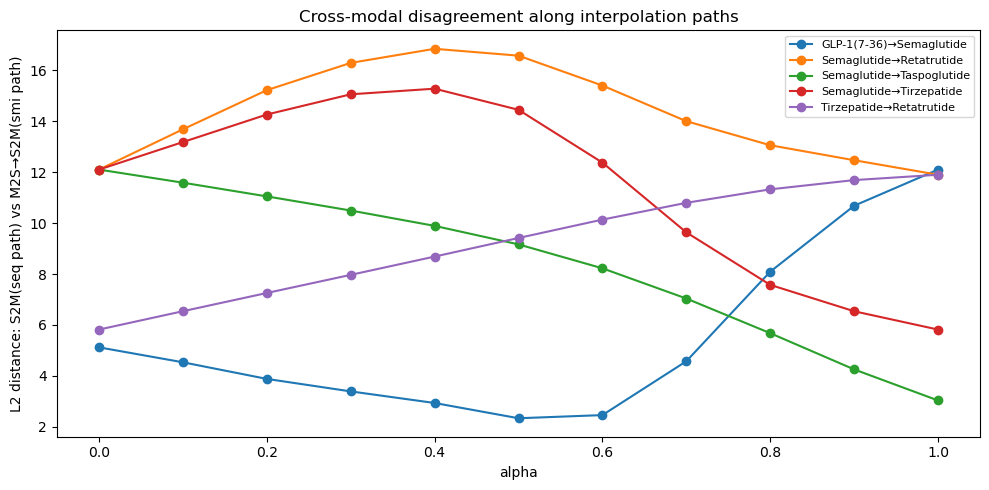

In [17]:
def find_milestone_index(name):
    # exact first
    matches = np.where(names_all == name)[0]
    if len(matches): return int(matches[0])
    # case-insensitive contains fallback
    lname = name.lower().replace(' ', '')
    cand = [i for i, n in enumerate(names_all) if lname in str(n).lower().replace(' ', '')]
    if cand: return int(cand[0])
    raise KeyError(f'Cannot find milestone name: {name}')

def interp_cond(c1, c2, alpha, mode='interp'):
    c1 = np.asarray(c1, dtype='float32')
    c2 = np.asarray(c2, dtype='float32')
    if mode == 'source': return c1
    if mode == 'target': return c2
    if mode == 'interp': return (1-alpha)*c1 + alpha*c2
    raise ValueError('mode must be source/target/interp')

INTERP_PATHS = [
    ('GLP-1(7-36)', 'Semaglutide'),
    ('Semaglutide', 'Tirzepatide'),
    ('Tirzepatide', 'Retatrutide'),
    ('Semaglutide', 'Retatrutide'),
    ('Semaglutide', 'Taspoglutide'),
]
INTERP_STEPS = 11
INTERP_COND_MODE = 'interp'
RUN_INTERP_DECODING = True
N_INTERP_DECODE_SAMPLES = 5  # 너무 오래 걸리면 1~3으로 줄이세요.

@torch.no_grad()
def bridge_s2m_one(zseq_scaled, cond_vec):
    z = torch.tensor(np.asarray(zseq_scaled, dtype='float32').reshape(1,-1), device=DEVICE)
    c = torch.tensor(np.asarray(cond_vec, dtype='float32').reshape(1,-1), device=DEVICE)
    return bridge_s2m(z, c).cpu().numpy()[0]

@torch.no_grad()
def bridge_m2s_one(zsmi_scaled, cond_vec):
    z = torch.tensor(np.asarray(zsmi_scaled, dtype='float32').reshape(1,-1), device=DEVICE)
    c = torch.tensor(np.asarray(cond_vec, dtype='float32').reshape(1,-1), device=DEVICE)
    return bridge_m2s(z, c).cpu().numpy()[0]

def decode_prop_summary_from_scaled_zsmi(z_scaled, cond_vec, label, n_samples=N_INTERP_DECODE_SAMPLES):
    z_raw = smi_scaler.inverse_transform(np.asarray(z_scaled, dtype='float32').reshape(1,-1))[0]
    # temporarily use sample n_samples candidates and average properties of valid candidates
    cands = decode_candidates_from_raw_z(z_raw, cond_vec, method='sample', n_samples=n_samples)
    props = [mol_props(s) for s in cands]
    valid_props = [p for p in props if p['valid']]
    out = {f'{label}_valid_n': len(valid_props)}
    for key in ['MW','LogP','TPSA','amide','alkyl_proxy']:
        vals = [p[key] for p in valid_props if not pd.isna(p[key])]
        out[f'{label}_{key}_mean'] = float(np.mean(vals)) if vals else np.nan
        out[f'{label}_{key}_std'] = float(np.std(vals)) if vals else np.nan
    return out

interp_rows = []
for src, tgt in INTERP_PATHS:
    try:
        i = find_milestone_index(src)
        j = find_milestone_index(tgt)
    except KeyError as e:
        print('[skip]', e)
        continue
    for alpha in np.linspace(0, 1, INTERP_STEPS):
        c = interp_cond(C_raw[i], C_raw[j], alpha, INTERP_COND_MODE)
        zseq_a = (1-alpha)*Z_seq[i] + alpha*Z_seq[j]
        zsmi_a = (1-alpha)*Z_smi[i] + alpha*Z_smi[j]
        zsmi_from_seq = bridge_s2m_one(zseq_a, c)
        zseq_from_smi = bridge_m2s_one(zsmi_a, c)
        zsmi_from_smi_cycle = bridge_s2m_one(zseq_from_smi, c)
        z_consensus = 0.5 * (zsmi_from_seq + zsmi_from_smi_cycle)
        row = {
            'source': src,
            'target': tgt,
            'alpha': float(alpha),
            'seq_vs_smi_cycle_l2': float(np.linalg.norm(zsmi_from_seq - zsmi_from_smi_cycle)),
            'seq_vs_smi_cycle_cos': float(cosine_rows(zsmi_from_seq.reshape(1,-1), zsmi_from_smi_cycle.reshape(1,-1))[0]),
            'seq_vs_direct_smi_l2': float(np.linalg.norm(zsmi_from_seq - zsmi_a)),
            'cycle_vs_direct_smi_l2': float(np.linalg.norm(zsmi_from_smi_cycle - zsmi_a)),
        }
        if RUN_INTERP_DECODING:
            row.update(decode_prop_summary_from_scaled_zsmi(zsmi_from_seq, c, 'SEQpath'))
            row.update(decode_prop_summary_from_scaled_zsmi(zsmi_a, c, 'SMIpath'))
            row.update(decode_prop_summary_from_scaled_zsmi(z_consensus, c, 'Consensus'))
        interp_rows.append(row)

interp_df = pd.DataFrame(interp_rows)
interp_df.to_csv(TAB_DIR / 'cross_modal_disagreement_interpolation.csv', index=False)
display(interp_df.head(20))

# Plot disagreement per path
plt.figure(figsize=(10, 5))
for (src, tgt), g in interp_df.groupby(['source','target']):
    plt.plot(g['alpha'], g['seq_vs_smi_cycle_l2'], marker='o', label=f'{src}→{tgt}')
plt.xlabel('alpha')
plt.ylabel('L2 distance: S2M(seq path) vs M2S→S2M(smi path)')
plt.title('Cross-modal disagreement along interpolation paths')
plt.legend(fontsize=8)
plt.tight_layout()
plt.savefig(FIG_DIR / 'cross_modal_disagreement_l2.png', dpi=220, bbox_inches='tight')
plt.show()


## 17. Optional property trajectory plots

`RUN_INTERP_DECODING=True`일 때만 property trajectory를 그립니다. 이 결과는 “더 좋은 consensus 생성”이 아니라 **cross-modal agreement/disagreement diagnostic**으로 해석하세요.


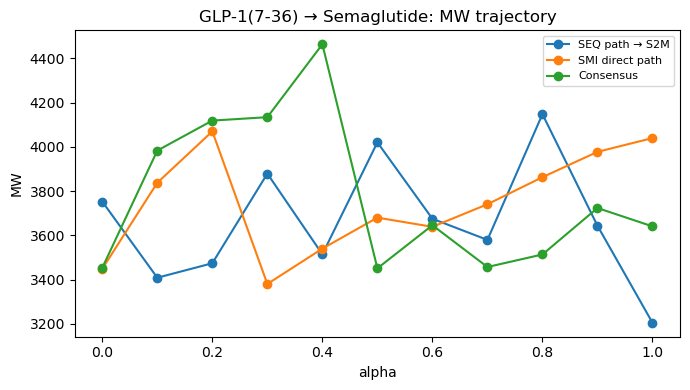

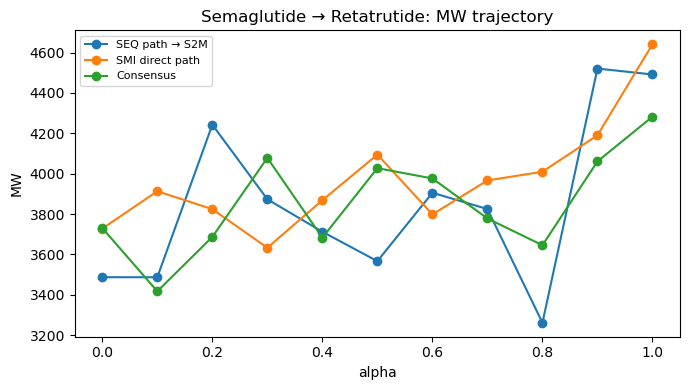

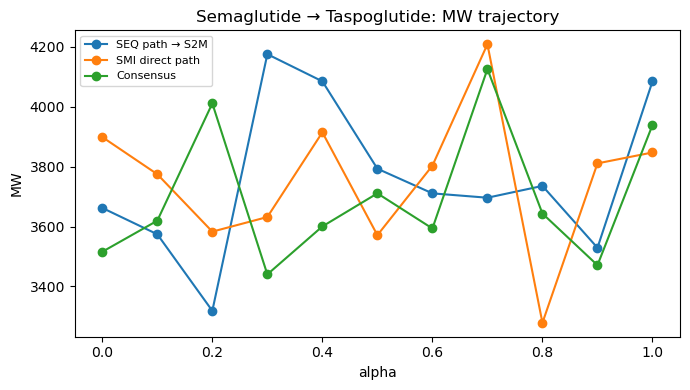

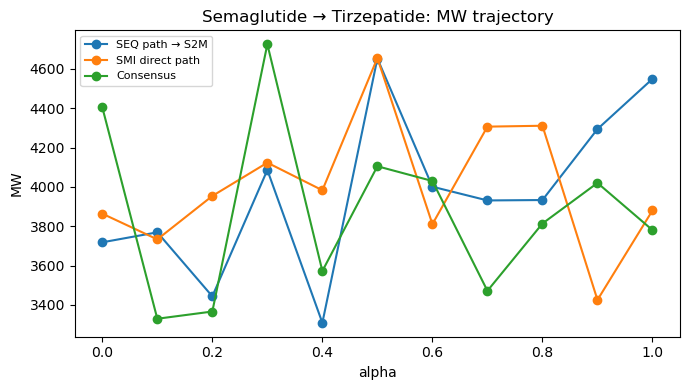

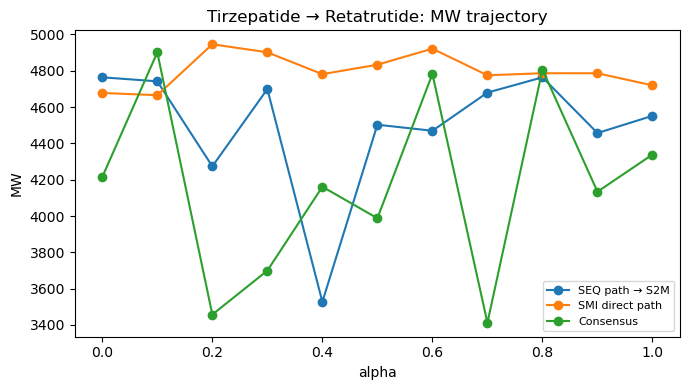

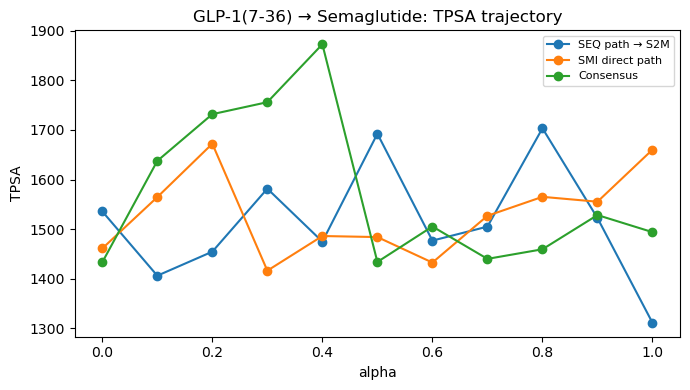

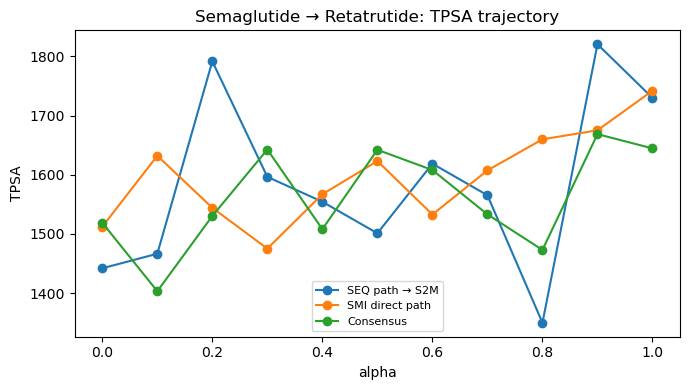

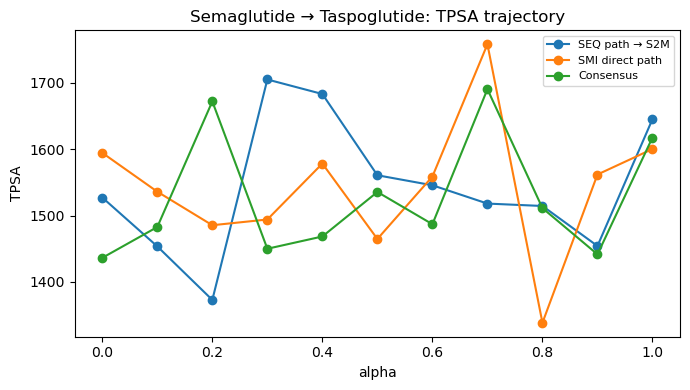

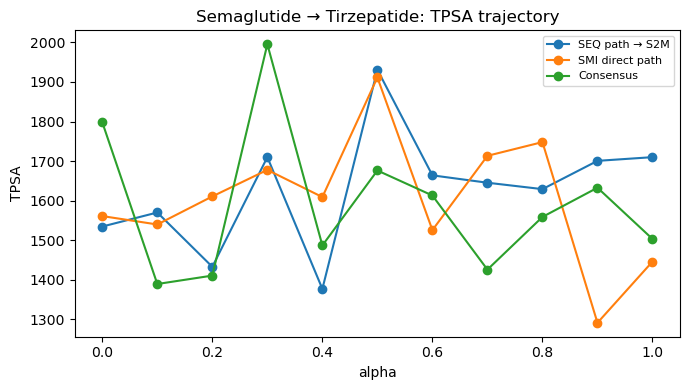

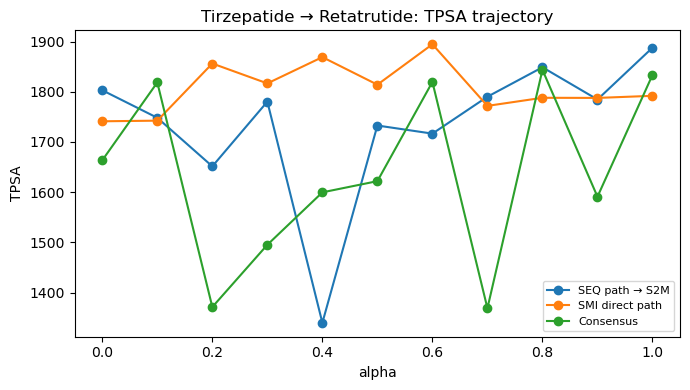

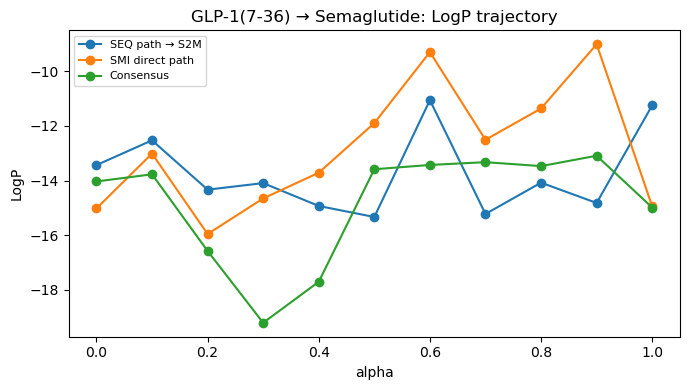

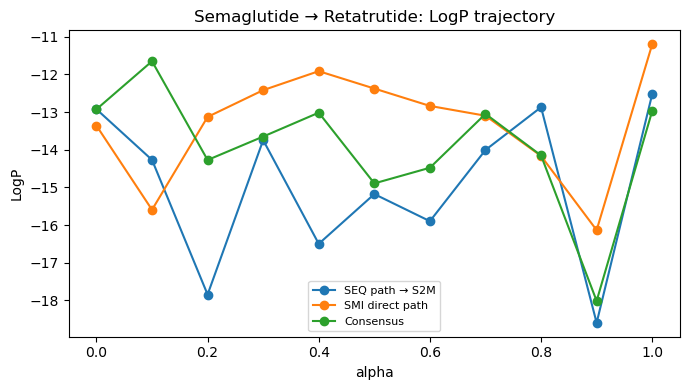

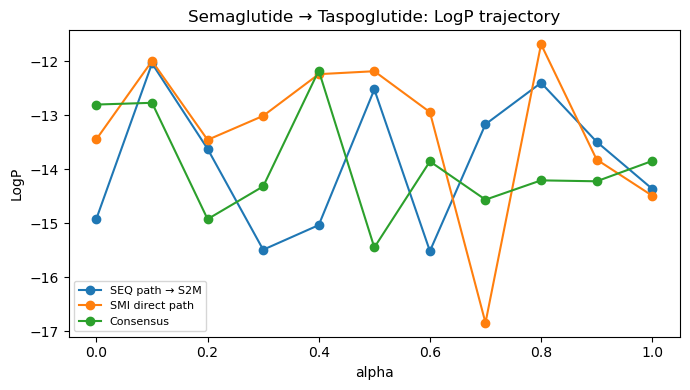

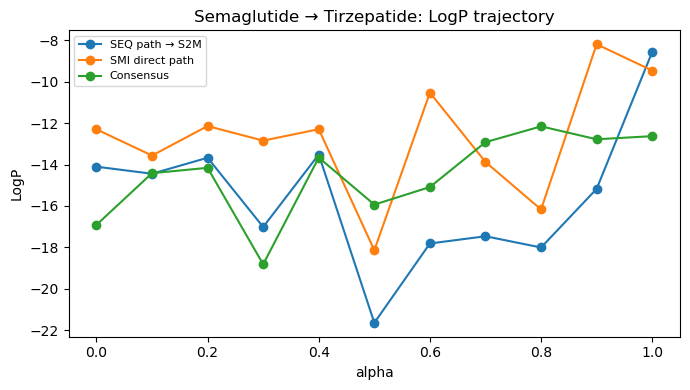

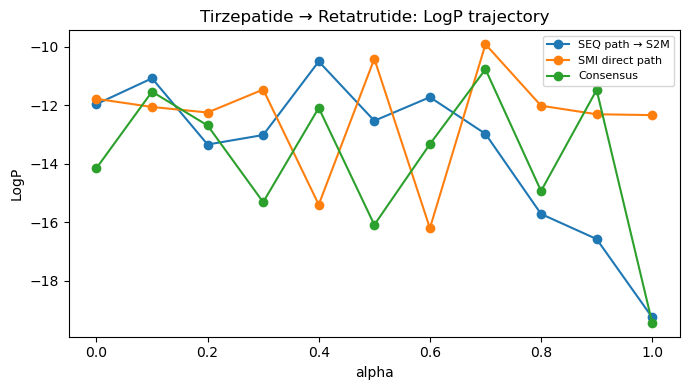

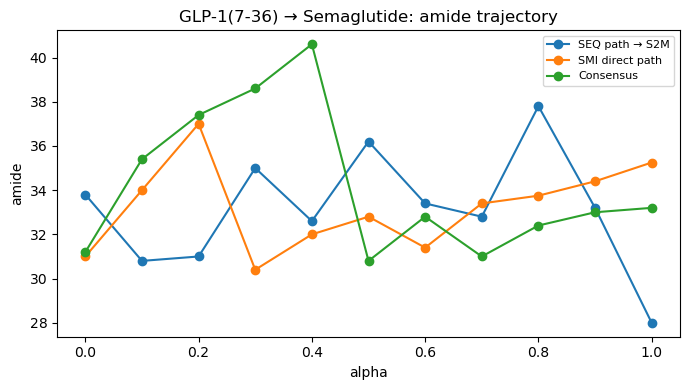

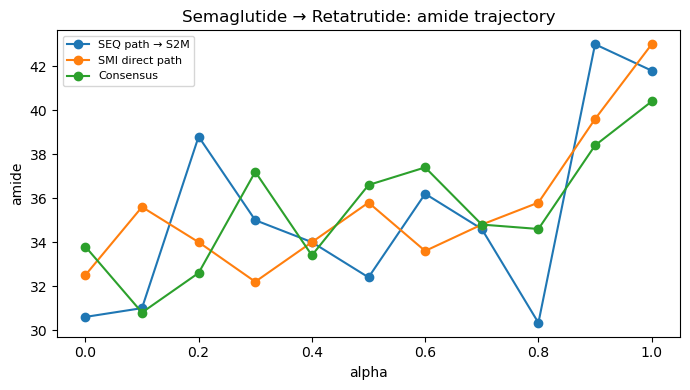

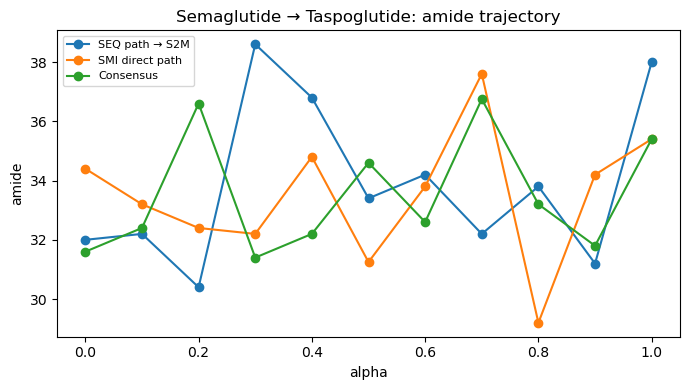

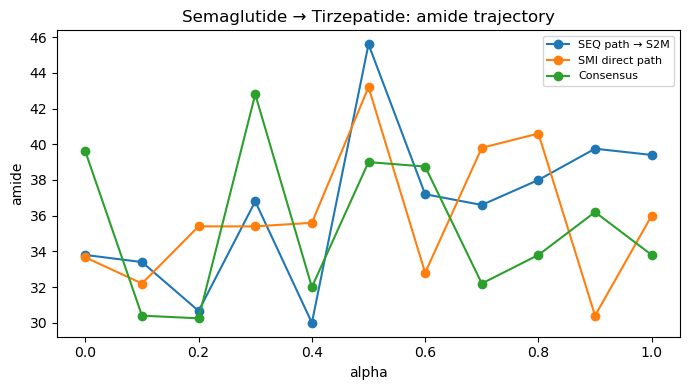

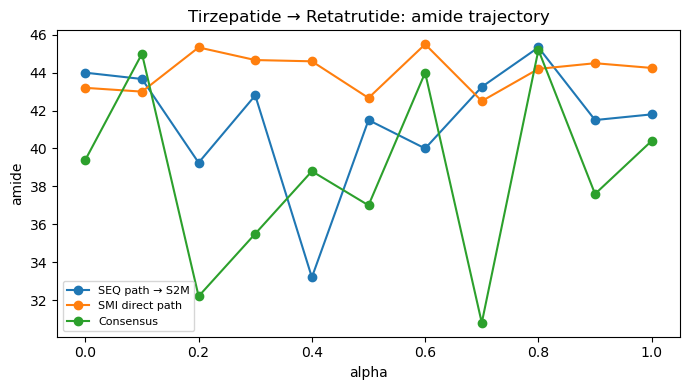

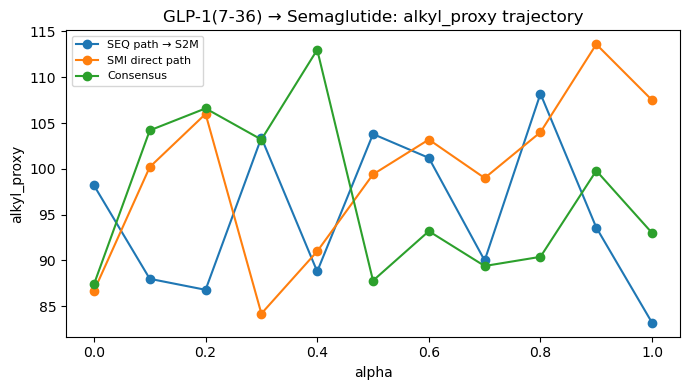

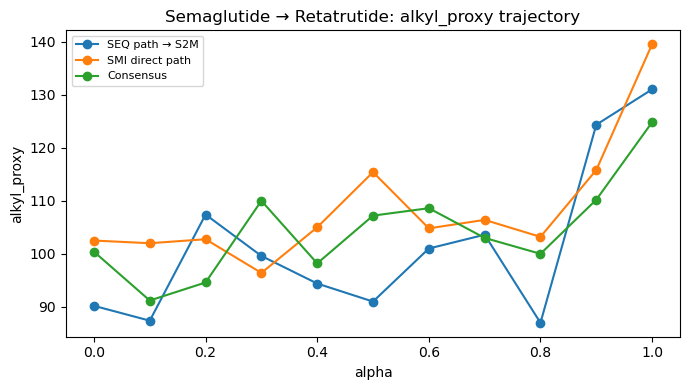

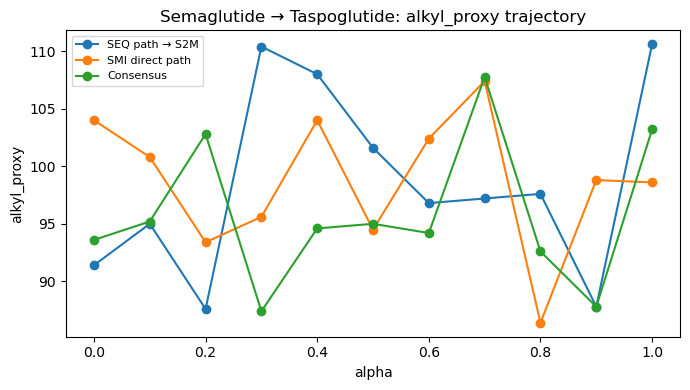

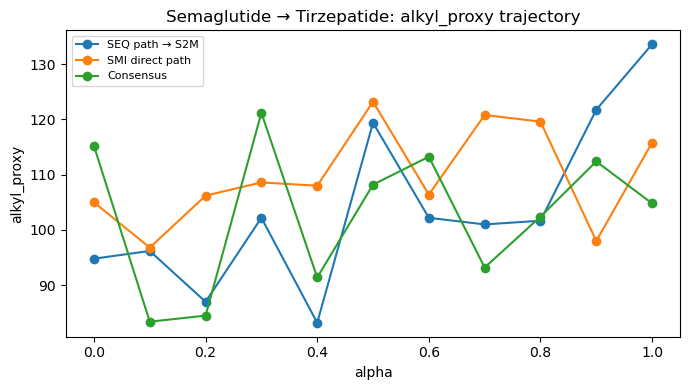

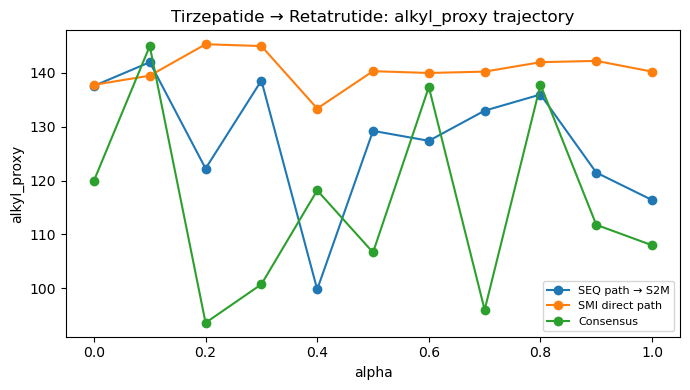

In [18]:
if RUN_INTERP_DECODING and len(interp_df):
    for prop in ['MW','TPSA','LogP','amide','alkyl_proxy']:
        cols = [f'SEQpath_{prop}_mean', f'SMIpath_{prop}_mean', f'Consensus_{prop}_mean']
        if not all(c in interp_df.columns for c in cols):
            continue
        for (src, tgt), g in interp_df.groupby(['source','target']):
            plt.figure(figsize=(7,4))
            plt.plot(g['alpha'], g[cols[0]], marker='o', label='SEQ path → S2M')
            plt.plot(g['alpha'], g[cols[1]], marker='o', label='SMI direct path')
            plt.plot(g['alpha'], g[cols[2]], marker='o', label='Consensus')
            plt.title(f'{src} → {tgt}: {prop} trajectory')
            plt.xlabel('alpha')
            plt.ylabel(prop)
            plt.legend(fontsize=8)
            plt.tight_layout()
            safe = (src + '_to_' + tgt).replace('/','_').replace(' ','_').replace('(','').replace(')','')
            plt.savefig(FIG_DIR / f'interp_{safe}_{prop}.png', dpi=200, bbox_inches='tight')
            plt.show()
else:
    print('Interpolation decoding disabled or no interpolation data.')


# 18. Final summary export

주요 결과 파일 위치를 출력합니다.


In [19]:
print('Experiment directory:', EXP_DIR)
print('\nTables:')
for p in sorted(TAB_DIR.glob('*.csv')):
    print(' -', p)
print('\nFigures:')
for p in sorted(FIG_DIR.glob('*.png')):
    print(' -', p)

summary_notes = {
    'main_interpretation': 'Bridge aligns shared low-dimensional receptor/family-level structure rather than exact molecule identity.',
    'recommended_core_tables': [
        'latent_collapse_diagnostics.csv',
        'retrieval_baselines_condition_ablation.csv',
        'per_drug_retrieval_MLP_S2M_test.csv',
        'group_level_retrieval_MLP_test.csv',
        'smiles_decode_tanimoto_gap_test.csv',
        'modification_residual_analysis_test.csv',
        'direction_asymmetry_MLP.csv',
    ],
    'recommended_core_figures': [
        'latent_variance_sorted.png',
        'pca_true_vs_bridge_test_condition.png',
        'modification_residual_l2_test.png',
        'tanimoto_gap_true_minus_s2m_test.png',
        'cross_modal_disagreement_l2.png',
    ]
}
with open(EXP_DIR / 'summary_notes.json', 'w', encoding='utf-8') as f:
    json.dump(summary_notes, f, indent=2, ensure_ascii=False)
print('\nSaved summary_notes.json')


Experiment directory: MLProject/bridge/bridge_final3_followup_experiments

Tables:
 - MLProject/bridge/bridge_final3_followup_experiments/tables/cross_modal_disagreement_interpolation.csv
 - MLProject/bridge/bridge_final3_followup_experiments/tables/direction_asymmetry_MLP.csv
 - MLProject/bridge/bridge_final3_followup_experiments/tables/full_cycle_vs_direct_s2m_tanimoto.csv
 - MLProject/bridge/bridge_final3_followup_experiments/tables/group_level_retrieval_MLP_test.csv
 - MLProject/bridge/bridge_final3_followup_experiments/tables/latent_collapse_diagnostics.csv
 - MLProject/bridge/bridge_final3_followup_experiments/tables/m2s_sequence_decode_sanity_test.csv
 - MLProject/bridge/bridge_final3_followup_experiments/tables/modification_residual_analysis_test.csv
 - MLProject/bridge/bridge_final3_followup_experiments/tables/per_drug_retrieval_MLP_M2S_test.csv
 - MLProject/bridge/bridge_final3_followup_experiments/tables/per_drug_retrieval_MLP_S2M_test.csv
 - MLProject/bridge/bridge_final3_f